# Setting up the mesh and coordinates of the Nodes

In [1]:
import numpy as np
import scipy.linalg as scp
import matplotlib.pylab as plt
import time
from scipy.optimize import fsolve
import pandas as pd
from scipy.interpolate import interp1d
from scipy.interpolate import LinearNDInterpolator
from scipy.interpolate import NearestNDInterpolator

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

Beam length             : 11000.000 m
Number of elements      : 1760
Number of nodes         : 1761
Actual element length   : 6.250 m
[[   0    1]
 [   1    2]
 [   2    3]
 ...
 [1757 1758]
 [1758 1759]
 [1759 1760]]


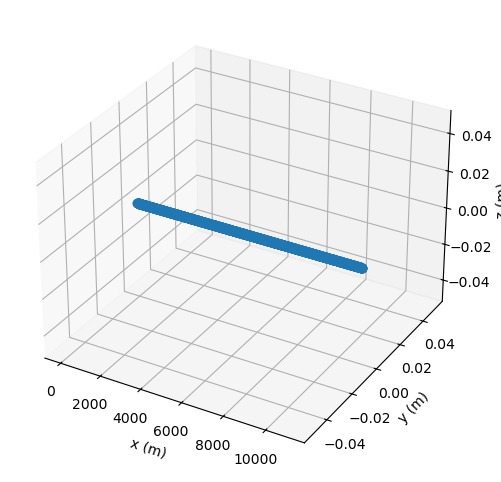

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

L = 11000.0     
Le = 6.25     

nEle = max(1, int(round(L / Le)))
actual_Le = L / nEle
nNodes = nEle + 1

x = np.linspace(0, L, nNodes)
y = np.zeros_like(x)
z = np.zeros_like(x)


elements = np.column_stack([
    np.arange(nEle),
    np.arange(1, nEle + 1)
])

print(f"Beam length             : {L:.3f} m")
print(f"Number of elements      : {nEle}")
print(f"Number of nodes         : {nNodes}")
print(f"Actual element length   : {actual_Le:.3f} m")
print(elements)


fig = plt.figure()
ax = plt.axes(projection="3d")
ax.plot(x, y, z, "-o", lw=2)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
plt.grid(True)
plt.show()

## Define beam properties

In [ ]:
E = 39e9                                 
G = 16.3e9                                 
h_out = 6                                  
h_in = 5                                  
w_out = 5.5                                
w_in = 4.5                                
connector_thickness = 0.5



connector_spacing = 250                              
hm = 6-connector_thickness
bm = 5.5-connector_thickness
Am = hm*bm
pm = 2*(hm+bm)                                                  
Concrete_density = 2600                                        
TunArea = 6*5.5 - 5*4.5                                  
connector_GJ = G*(2*connector_thickness**2 * bm**2 * hm**2/(bm+hm))                           
connector_Im = 2600* (bm**2 + hm**2)**2 * bm*hm*connector_thickness / 144       
connector_m =  (TunArea) *2600                                
connector_EIy = 1/12 * (w_out**3*h_out - w_in**3*h_in) * E      
connector_EIz = 1/12 * (w_out*h_out**3 - w_in*h_in**3) * E      
connector_EA = (6 * 5.5 - 5 * 4.5) * E     


GJ_eff_connector = connector_GJ / connector_spacing
Im_eff_connector = connector_Im / connector_spacing
EIy_eff_connector = connector_EIy / connector_spacing
EIz_eff_connector = connector_EIz / connector_spacing
EA_eff_connector = connector_EA / connector_spacing
m_eff_connector = connector_m / connector_spacing



Beam_GJ = 9.5e12 * 2 +  GJ_eff_connector   
Beam_Im = 1.5e6 * 2 +  Im_eff_connector            
Beam_m = 1.1e5 * 2 +  m_eff_connector             
Beam_EIy = 141193e9 * 2 +  EIy_eff_connector        
Beam_EIz = 141193e9 * 2 +  EIz_eff_connector       
Beam_EA = 15.5*39e9 * 2 +  EA_eff_connector         

In [4]:
print("Beam_EIy:", Beam_EIy)
print("Beam_EIz:", Beam_EIz)
print("Beam_EA:", Beam_EA)
print("Beam_m:", Beam_m)

Beam_EIy: 282393054125000.0
Beam_EIz: 282394131500000.0
Beam_EA: 1210638000000.0
Beam_m: 220109.2


# Mesh setup


In [5]:
NodeC = [[x, y, z] for x, y, z in zip(x, y, z)]
nNodes = len(NodeC)

Ele_tunnel = [
    [n1, n1 + 1, Beam_m, Beam_EA, Beam_EIy, Beam_EIz, Beam_GJ, Beam_Im]
    for n1 in range(0, nNodes - 1)]

escape_spacing = 250.0
NodeArr = np.array(NodeC, dtype=float)

print(f"Total nodes : {nNodes}")
print(NodeC)
print(NodeArr)
print(len(NodeArr))

Total nodes : 1761
[[np.float64(0.0), np.float64(0.0), np.float64(0.0)], [np.float64(6.25), np.float64(0.0), np.float64(0.0)], [np.float64(12.5), np.float64(0.0), np.float64(0.0)], [np.float64(18.75), np.float64(0.0), np.float64(0.0)], [np.float64(25.0), np.float64(0.0), np.float64(0.0)], [np.float64(31.25), np.float64(0.0), np.float64(0.0)], [np.float64(37.5), np.float64(0.0), np.float64(0.0)], [np.float64(43.75), np.float64(0.0), np.float64(0.0)], [np.float64(50.0), np.float64(0.0), np.float64(0.0)], [np.float64(56.25), np.float64(0.0), np.float64(0.0)], [np.float64(62.5), np.float64(0.0), np.float64(0.0)], [np.float64(68.75), np.float64(0.0), np.float64(0.0)], [np.float64(75.0), np.float64(0.0), np.float64(0.0)], [np.float64(81.25), np.float64(0.0), np.float64(0.0)], [np.float64(87.5), np.float64(0.0), np.float64(0.0)], [np.float64(93.75), np.float64(0.0), np.float64(0.0)], [np.float64(100.0), np.float64(0.0), np.float64(0.0)], [np.float64(106.25), np.float64(0.0), np.float64(0.0)],

# Add mooring 

In [ ]:
mooring_spacing = 25.0

s = np.linspace(0, L, nNodes)
target_spacing = np.arange(0.0, L + 0.5 * mooring_spacing, mooring_spacing)

mooring_nodes = np.unique([
    int(np.argmin(np.abs(s - target)))
    for target in target_spacing
])

print("Mooring target positions:", target_spacing)
print("Mooring node indices:", mooring_nodes)
print("Mooring node positions:", s[mooring_nodes])


Mooring target positions: [    0.    25.    50.    75.   100.   125.   150.   175.   200.   225.
   250.   275.   300.   325.   350.   375.   400.   425.   450.   475.
   500.   525.   550.   575.   600.   625.   650.   675.   700.   725.
   750.   775.   800.   825.   850.   875.   900.   925.   950.   975.
  1000.  1025.  1050.  1075.  1100.  1125.  1150.  1175.  1200.  1225.
  1250.  1275.  1300.  1325.  1350.  1375.  1400.  1425.  1450.  1475.
  1500.  1525.  1550.  1575.  1600.  1625.  1650.  1675.  1700.  1725.
  1750.  1775.  1800.  1825.  1850.  1875.  1900.  1925.  1950.  1975.
  2000.  2025.  2050.  2075.  2100.  2125.  2150.  2175.  2200.  2225.
  2250.  2275.  2300.  2325.  2350.  2375.  2400.  2425.  2450.  2475.
  2500.  2525.  2550.  2575.  2600.  2625.  2650.  2675.  2700.  2725.
  2750.  2775.  2800.  2825.  2850.  2875.  2900.  2925.  2950.  2975.
  3000.  3025.  3050.  3075.  3100.  3125.  3150.  3175.  3200.  3225.
  3250.  3275.  3300.  3325.  3350.  3375.  3400.  

# Global Matrixes

In [ ]:
LDOF = 6
nDof = LDOF*nNodes 
K = np.zeros(nDof*nDof)
M = np.zeros(nDof*nDof)
Q = np.zeros(nDof*nDof)

from BeamMatrices2 import Beam3DMatrices

for iEle in range(0, nEle):
    n1, n2, m, EA, EIy, EIz, GJ, Im = Ele_tunnel[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    
    n1dof = LDOF*n1 + np.arange(0,LDOF)
    n2dof = LDOF*n2 + np.arange(0,LDOF)    
    
    Me, Ke, Qe = Beam3DMatrices(m, EA, EIy, EIz, GJ, Im, (NodeC[n1], NodeC[n2]) )
    
    indexes = np.append(n1dof, n2dof)
    for i in range(0, 2*LDOF):
        for j in range(0, 2*LDOF):
            ij = indexes[i]*nDof + indexes[j]
            #print(ij)
            M[ij] = M[ij] + Me[i,j]
            K[ij] = K[ij] + Ke[i,j]
            Q[ij] = Q[ij] + Qe[i,j]

M = M.reshape((nDof, nDof))
K = K.reshape((nDof, nDof))
Q = Q.reshape((nDof, nDof))


M_lumped = np.zeros_like(M)

for iEle in range(nEle):
    n1, n2, m, EA, EIy, EIz, GJ, Im = Ele_tunnel[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))

    L_ele = np.linalg.norm(np.array(NodeC[n2]) - np.array(NodeC[n1]))

    M_node = m * L_ele / 2
    Jx_node = Beam_Im * L_ele / 2
    J_bend_y = Beam_EIy * L_ele / 2
    J_bend_z = Beam_EIz * L_ele / 2

    for node in [n1, n2]:
        i = node * LDOF
        M_lumped[i + 0, i + 0] += M_node
        M_lumped[i + 1, i + 1] += M_node
        M_lumped[i + 2, i + 2] += M_node

        M_lumped[i + 3, i + 3] += Jx_node
        M_lumped[i + 4, i + 4] += J_bend_y
        M_lumped[i + 5, i + 5] += J_bend_z

M = M_lumped


# Add Added-Mass, Mooring stiffness and Added Damping

In [ ]:
rho_w = 1025.0      
Cm = 1.0            
D_outer = 12.7      
A_disp = np.pi * D_outer**2 / 4
sensitivity_factor = 0.5  
m_added = rho_w * Cm * A_disp * (sensitivity_factor)  

M_added = m_added * Q

M = M + M_added

print("Added mass per meter:", round(m_added, 2), "kg/m")
print("Structural mass per meter:", round(Beam_m, 2), "kg/m")
print("Added/structural mass ratio:", round(m_added / Beam_m, 2))


n_stiff = 360
half_n = n_stiff // 2

k_start_v = 45
k_start_h = 161

k_mid_v = 60
k_mid_h = 396

k_end_v = 81
k_end_h = 843

k_v = np.linspace(k_start_v, k_mid_v, half_n + 1)
k_h = np.linspace(k_start_h, k_mid_h, half_n + 1)


print(k_v)
print(k_h)

Added mass per meter: 64921.9 kg/m
Structural mass per meter: 220109.2 kg/m
Added/structural mass ratio: 0.29
[45.         45.08333333 45.16666667 45.25       45.33333333 45.41666667
 45.5        45.58333333 45.66666667 45.75       45.83333333 45.91666667
 46.         46.08333333 46.16666667 46.25       46.33333333 46.41666667
 46.5        46.58333333 46.66666667 46.75       46.83333333 46.91666667
 47.         47.08333333 47.16666667 47.25       47.33333333 47.41666667
 47.5        47.58333333 47.66666667 47.75       47.83333333 47.91666667
 48.         48.08333333 48.16666667 48.25       48.33333333 48.41666667
 48.5        48.58333333 48.66666667 48.75       48.83333333 48.91666667
 49.         49.08333333 49.16666667 49.25       49.33333333 49.41666667
 49.5        49.58333333 49.66666667 49.75       49.83333333 49.91666667
 50.         50.08333333 50.16666667 50.25       50.33333333 50.41666667
 50.5        50.58333333 50.66666667 50.75       50.83333333 50.91666667
 51.         5

Sum of stiffness matrix before applying boundary conditions: 1.908528857664e+18


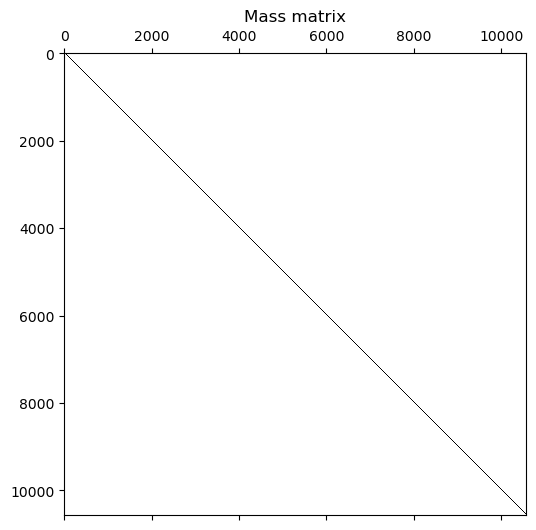

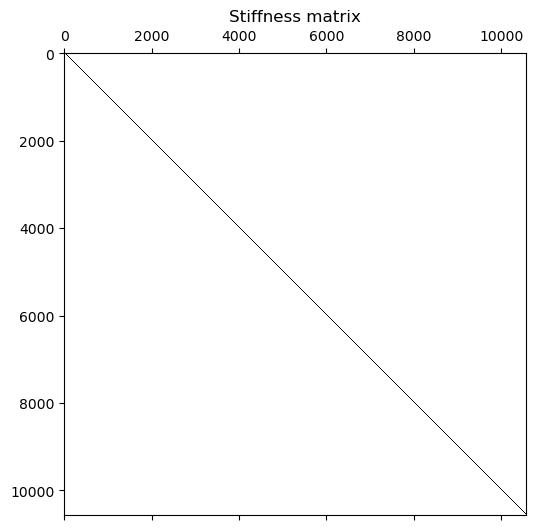

In [9]:
plt.figure()
plt.spy(M)
plt.title("Mass matrix")
plt.figure()
plt.spy(K)
plt.title("Stiffness matrix")
K_sum_before = np.sum(K)
print("Sum of stiffness matrix before applying boundary conditions:", K_sum_before)
pass

# Matrixes after adding stiffness and Mass

In [ ]:
K_before = K.copy()

cat_i = 0
added = 0.0

def AddMooringSpringHV(K, node_id, kh, kv, LDOF=6):
    """
    Adds horizontal and vertical mooring tangent stiffness
    to one 3D beam node.

    DOF order per node:
    [ux, uy, uz, rx, ry, rz]

    kh = horizontal transverse stiffness [N/m]
    kv = vertical stiffness [N/m]
    """

    i = int(node_id) * LDOF

    K[i + 1, i + 1] += kh   
    K[i + 2, i + 2] += kv   
    return K

for node in mooring_nodes:
    s_moor = s[node]

    if s_moor < 1000:
        kh = 120e3
        kv = 85e3

    elif 1000 <= s_moor < 10000:
        idx = min(cat_i, len(k_h) - 1)
        kh = k_h[idx] * 1e2
        kv = k_v[idx] * 1e3
        cat_i += 1

    else:
        kh = 120e3
        kv = 85e3

    K = AddMooringSpringHV(K, node, kh, kv, LDOF=LDOF)
    added += kh + kv

K_after = K.copy()

print("Expected added stiffness:", added)
print("Actual added diagonal stiffness:", np.sum(np.diag(K_after - K_before)))

for node in mooring_nodes:
    dof_y = node * LDOF + 1
    dof_z = node * LDOF + 2

    print(
        f"Node {node}: "
        f"ΔK_uy = {K_after[dof_y, dof_y] - K_before[dof_y, dof_y]:.3e}, "
        f"ΔK_uz = {K_after[dof_z, dof_z] - K_before[dof_z, dof_z]:.3e}"
    )

for i in range(min(10, nNodes)):
    print(
        M[i*LDOF+3, i*LDOF+3],  
        M[i*LDOF+4, i*LDOF+4],  
        M[i*LDOF+5, i*LDOF+5],  
    )

Expected added stiffness: 48976750.0
Actual added diagonal stiffness: 48976750.0
Node 0: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 4: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 8: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 12: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 16: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 20: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 24: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 28: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 32: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 36: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 40: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 44: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 48: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 52: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 56: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 60: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 64: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 68: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 72: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 76: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
No

In [ ]:
NodesClamp = (0, nNodes-1)

DofsP = np.empty([0], dtype=int)
for n0 in NodesClamp:
    DofsP = np.append(DofsP, n0*LDOF + np.arange(0,LDOF))

DofsP = np.empty([0], dtype=int)
for n0 in NodesClamp:
    DofsP = np.append(
        DofsP,
        n0*LDOF + np.array([0,1,2])
    )
    
DofsF = np.arange(0, nDof)      
DofsF = np.delete(DofsF, DofsP)  

print(DofsP)
print(DofsF)

def AddRotationalSpring(K, node_id, krx, kry, krz, LDOF=6):

    i = node_id * LDOF

    K[i+3, i+3] += krx
    K[i+4, i+4] += kry
    K[i+5, i+5] += krz

    return K

krx_end = Beam_Im * 100  
kry_end = Beam_EIy * 10  
krz_end = Beam_EIz * 10  

for node in NodesClamp:
    K = AddRotationalSpring(K, node, krx_end, kry_end, krz_end, LDOF=LDOF)


M_FF = M[np.ix_(DofsF, DofsF)]
K_FF = K[np.ix_(DofsF, DofsF)]
Q_FF = Q[np.ix_(DofsF, DofsF)]


print("K shape:", K.shape)
print("K_FF shape:", K_FF.shape)
print("Number of prescribed DOFs:", len(DofsP))
print("Number of free DOFs:", len(DofsF))
pass

[    0     1     2 10560 10561 10562]
[    3     4     5 ... 10563 10564 10565]
K shape: (10566, 10566)
K_FF shape: (10560, 10560)
Number of prescribed DOFs: 6
Number of free DOFs: 10560


# Eigen frequencies and Modal Shapes

### Add rotational stiffness to B.C nodes

In [12]:
from scipy.linalg import eigvalsh

m_eigs = eigvalsh(M_FF)

print("Smallest eigenvalues of M_FF:")
print(m_eigs[:20])
print("Number <= 0:", np.sum(m_eigs <= 0))

bad_modes = np.where(m_eigs <= 0)[0]

Smallest eigenvalues of M_FF:
[1510936.94647707 1510937.62928315 1510938.76441682 1510940.25343867
 1510942.16148491 1510944.54456521 1510947.29410816 1510950.53988714
 1510954.29102897 1510958.28684439 1510962.78613302 1510967.84338154
 1510973.16972837 1510978.94977655 1510985.23458994 1510991.96986619
 1510999.09868501 1511006.69191404 1511014.66106082 1511022.97630877]
Number <= 0: 0


In [13]:
Me, _, _ = Beam3DMatrices(
    Beam_m,
    Beam_EA,
    Beam_EIy,
    Beam_EIz,
    Beam_GJ,
    Beam_Im,
    (NodeC[0], NodeC[1])
)

eig = np.linalg.eigvalsh(Me)

print(np.min(eig))
print(eig)

-228921.61819613999
[-2.28921618e+05  1.99049583e+04  6.77395972e+04  8.96981706e+04
  2.29280417e+05  4.42136024e+05  6.87841250e+05  9.32799793e+05
  1.25193251e+06  1.51572828e+06  6.88536282e+11  2.06560885e+12]


In [ ]:
from scipy.sparse import csr_matrix

from scipy.linalg import eigh
import numpy as np

n_modes = 1000

w2, vr = eigh(K_FF, M_FF)

w2 = w2[:n_modes]
vr = vr[:, :n_modes]

w = np.sqrt(np.maximum(w2, 0))
f = w / (2*np.pi)

print(f)

[0.00034103 0.00034754 0.00037862 0.00038607 0.00038912 0.00039078
 0.00041898 0.00042173 0.00043011 0.00044085 0.0004619  0.00047486
 0.00049306 0.00051153 0.00052563 0.00053012 0.00056992 0.00057876
 0.0005822  0.00060257 0.00063914 0.00065263 0.00065463 0.00068307
 0.00070889 0.0007365  0.00073728 0.00075742 0.00078785 0.00081028
 0.0008225  0.00082396 0.00087238 0.00087779 0.00091042 0.00091227
 0.00095987 0.00096199 0.00099906 0.00100151 0.00104889 0.00105012
 0.00108748 0.00109121 0.00113861 0.0011395  0.00117321 0.00118108
 0.00122862 0.00122946 0.00124319 0.00127094 0.00129411 0.00131939
 0.00131973 0.00136044 0.00137162 0.00141006 0.00141006 0.00144871
 0.0014591  0.00150064 0.00150071 0.00153095 0.00154855 0.00158707
 0.00159131 0.00159152 0.0016386  0.00164842 0.00168201 0.00168211
 0.00172891 0.00173259 0.00177273 0.00177282 0.00181935 0.00182131
 0.00186348 0.00186352 0.00190991 0.00191111 0.00195421 0.00195429
 0.00200051 0.00200136 0.00204498 0.00204506 0.00209116 0.0020

In [16]:
f_1761nodes = [0.00034108, 0.00034756, 0.00037863, 0.00038624, 0.0003891, 0.00039054, 0.0004189, 0.00042165, 0.00043016, 0.00044086] # last two: 0.00046184, 0.00047479
f_881nodes = [0.00034101, 0.00034747, 0.00037854, 0.00038607, 0.00038898, 0.00039064, 0.00041887, 0.00042156, 0.00043006, 0.00044077] # last two: 0.0004618,  0.00047472
f_441nodes = [0.00034098, 0.00034744, 0.0003785, 0.00038603, 0.00038893, 0.0003906, 0.00041881, 0.0004215, 0.00043, 0.0004407] # last two: 0.00046172, 0.00047464
f_1761nodes = np.array(f_1761nodes)
f_881nodes = np.array(f_881nodes)
f_441nodes = np.array(f_441nodes)
err_881 = np.abs((f_881nodes - f_1761nodes) / f_1761nodes) * 100
err_441 = np.abs((f_441nodes - f_1761nodes) / f_1761nodes) * 100

df = pd.DataFrame({
    "Mode": np.arange(1, len(f_1761nodes) + 1),
    "f_441_nodes [Hz]": f_441nodes,
    "f_881_nodes [Hz]": f_881nodes,
    "f_1761_nodes [Hz]": f_1761nodes,
    "Error 441 vs 1761 [%]": err_441,
    "Error 881 vs 1761 [%]": err_881,
})

print(df.to_string(index=False))
print("\nMax error 441 nodes:", np.max(err_441), "%")
print("Max error 881 nodes:", np.max(err_881), "%")
print("Mean error 441 nodes:", np.mean(err_441), "%")
print("Mean error 881 nodes:", np.mean(err_881), "%")

 Mode  f_441_nodes [Hz]  f_881_nodes [Hz]  f_1761_nodes [Hz]  Error 441 vs 1761 [%]  Error 881 vs 1761 [%]
    1          0.000341          0.000341           0.000341               0.029319               0.020523
    2          0.000347          0.000347           0.000348               0.034526               0.025895
    3          0.000378          0.000379           0.000379               0.034334               0.023770
    4          0.000386          0.000386           0.000386               0.054370               0.044014
    5          0.000389          0.000389           0.000389               0.043691               0.030840
    6          0.000391          0.000391           0.000391               0.015363               0.025606
    7          0.000419          0.000419           0.000419               0.021485               0.007162
    8          0.000421          0.000422           0.000422               0.035575               0.021345
    9          0.000430          0.00

In [ ]:
Phi = np.zeros((nDof, n_modes))

for i in range(n_modes):
    Phi[DofsF, i] = vr[:, i]



def plot_mode(mode_id, scale=1.0, direction="z"):
    """
    mode_id starts from 0.
    direction = "y" or "z"
    """

    phi = Phi[:, mode_id]

    ux = phi[0::LDOF]
    uy = phi[1::LDOF]
    uz = phi[2::LDOF]

    if direction == "y":
        deformation = uy
        ylabel = "y displacement mode shape"
    elif direction == "z":
        deformation = uz
        ylabel = "z displacement mode shape"
    else:
        raise ValueError("direction must be 'y' or 'z'")

    deformation = deformation / np.max(np.abs(deformation))

    plt.figure()
    plt.plot(s, deformation, "-o")
    plt.xlabel("Beam coordinate s [m]")
    plt.ylabel(ylabel)
    plt.title(f"Mode {mode_id + 1}, f = {f[mode_id]:.4f} Hz")
    plt.grid(True)
    plt.show()



def plot_mode_3d(mode_id, scale=5.0):
    phi = Phi[:, mode_id]

    ux = phi[0::LDOF]
    uy = phi[1::LDOF]
    uz = phi[2::LDOF]

    max_disp = max(
        np.max(np.abs(ux)),
        np.max(np.abs(uy)),
        np.max(np.abs(uz))
    )

    ux = ux / max_disp
    uy = uy / max_disp
    uz = uz / max_disp

    x_def = x + scale * ux
    y_def = y + scale * uy
    z_def = z + scale * uz

    fig = plt.figure()
    ax = plt.axes(projection="3d")

    ax.plot(x, y, z, "k--", label="undeformed")
    ax.plot(x_def, y_def, z_def, "-o", label="mode shape")

    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("z [m]")
    ax.set_title(f"Mode {mode_id + 1}, f = {f[mode_id]:.4f} Hz")
    ax.legend()
    plt.show()


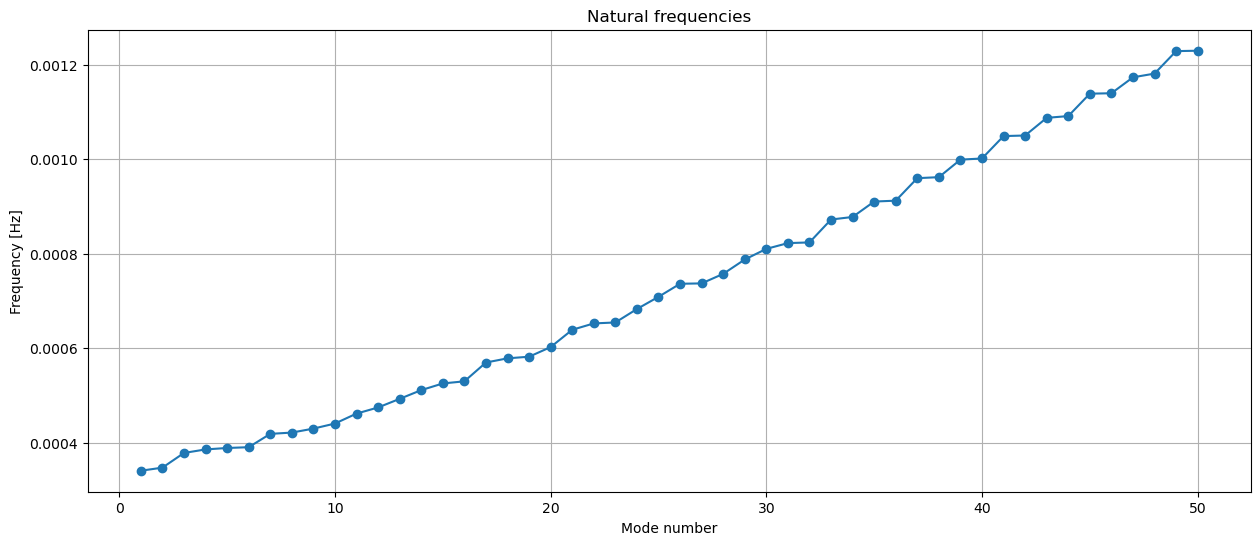

[0.00034103 0.00034754 0.00037862 0.00038607 0.00038912 0.00039078
 0.00041898 0.00042173 0.00043011 0.00044085]


In [18]:
plt.figure()
plt.plot(np.arange(1, len(f) + 1), f, "o-")
plt.xlabel("Mode number")
plt.ylabel("Frequency [Hz]")
plt.title("Natural frequencies")
plt.grid(True)
plt.show()
print(f[:10])

# Plotting Modal Shapes with corresponding Freq

In [ ]:

n_modes_available = vr.shape[1]

Phi = np.zeros((nDof, n_modes_available))
Phi[DofsF, :] = vr


def plot_mode_shapes_subplots(Phi, f, s, nModesPlot=1, direction="z"):

    dof_map = {
        "x": 0,
        "y": 1,
        "z": 2,
        "rx": 3,
        "ry": 4,
        "rz": 5,
    }

    local_dof = dof_map[direction]

    nModesPlot = min(nModesPlot, Phi.shape[1])

    ncols = 3
    nrows = int(np.ceil(nModesPlot / ncols))

    fig, axs = plt.subplots(
        nrows,
        ncols,
        figsize=(14, 3.5*nrows),
        sharex=True
    )

    axs = np.asarray(axs).ravel()

    for mode in range(nModesPlot):
        shape = Phi[local_dof::LDOF, mode]

        max_val = np.max(np.abs(shape))
        if max_val > 0:
            shape = shape / max_val

        axs[mode].plot(s, shape, "-o", markersize=3)
        axs[mode].axhline(0, linewidth=0.8)
        axs[mode].grid(True)
        axs[mode].set_title(f"Mode {mode+1}: f = {f[mode]:.4f} Hz")
        axs[mode].set_ylabel(direction)

    for ax in axs[nModesPlot:]:
        ax.axis("off")

    for ax in axs[-ncols:]:
        ax.set_xlabel("s [m]")

    fig.suptitle(f"Modal shapes in {direction}-direction", fontsize=14)
    plt.tight_layout()
    plt.show()

### Vertical Modal shapes

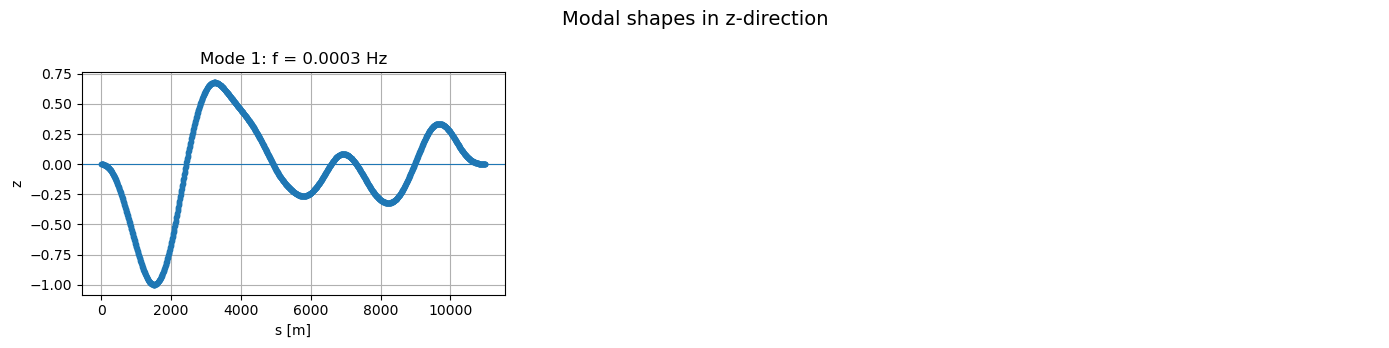

In [20]:
plot_mode_shapes_subplots(Phi, f, s, nModesPlot=1, direction="z")

### Horizontal Modal shapes

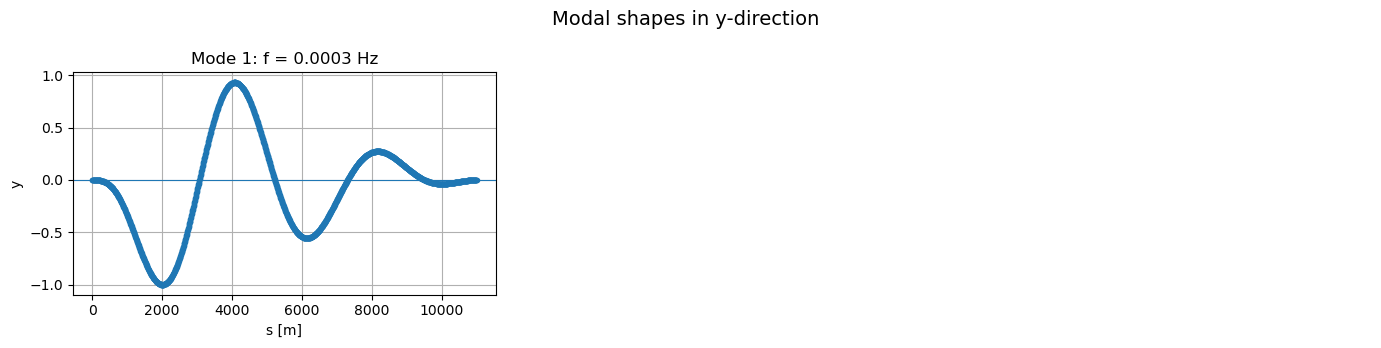

In [21]:
plot_mode_shapes_subplots(Phi, f, s, nModesPlot=1, direction="y")

### Rotational Modal shapes

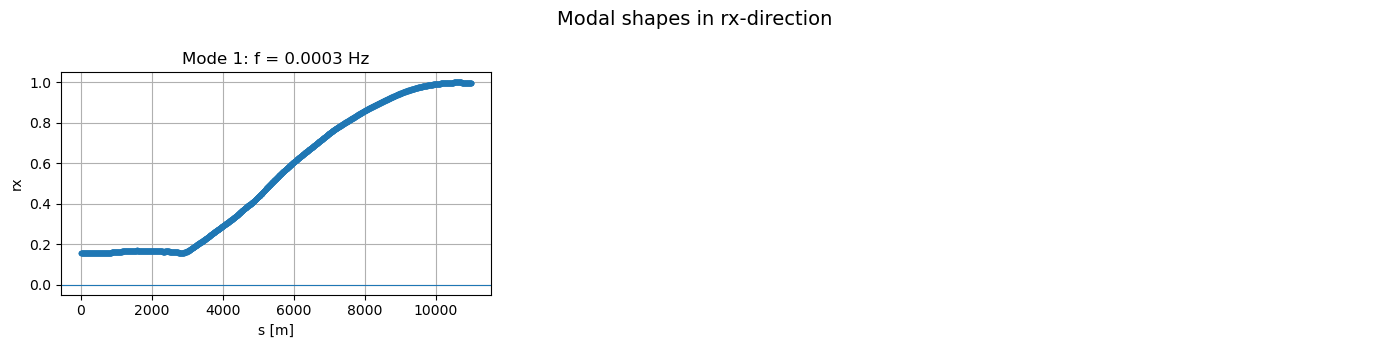

In [22]:
plot_mode_shapes_subplots(Phi, f, s, nModesPlot=1, direction="rx")

## Solving the Model Staticly

In [ ]:
qz = 250e3  
mooring_restoring_force = 2900e3 
element_length_factor = 25 / Le


Fz = np.zeros(nDof)

for iEle in range(nEle):
    n1 = int(Ele_tunnel[iEle][0])
    n2 = int(Ele_tunnel[iEle][1])

    Le = np.linalg.norm(np.asarray(NodeC[n2]) - np.asarray(NodeC[n1]))

    Fz[n1*LDOF + 2] += (qz * Le / 2) - (mooring_restoring_force / element_length_factor)
    Fz[n2*LDOF + 2] += (qz * Le / 2) - (mooring_restoring_force / element_length_factor)

F_Fz = Fz[DofsF]

u_Fz = np.linalg.solve(K_FF, F_Fz)

uz = np.zeros(nDof)
uz[DofsF] = u_Fz    


qy = 11e3  

Fy = np.zeros(nDof)

for iEle in range(nEle):
    n1 = int(Ele_tunnel[iEle][0])
    n2 = int(Ele_tunnel[iEle][1])

    Le = np.linalg.norm(np.asarray(NodeC[n2]) - np.asarray(NodeC[n1]))

    Fy[n1*LDOF + 1] += qy * Le / 2
    Fy[n2*LDOF + 1] += qy * Le / 2

F_Fy = Fy[DofsF]
print(F_Fy[:30])
print(np.max(np.abs(F_Fy)))

u_Fy = np.linalg.solve(K_FF, F_Fy)

uy = np.zeros(nDof)
uy[DofsF] = u_Fy


[    0.     0.     0.     0. 68750.     0.     0.     0.     0.     0.
 68750.     0.     0.     0.     0.     0. 68750.     0.     0.     0.
     0.     0. 68750.     0.     0.     0.     0.     0. 68750.     0.]
68750.0


In [24]:
print(F_Fy.sum())
print(qy*L)

120931250.0
121000000.0


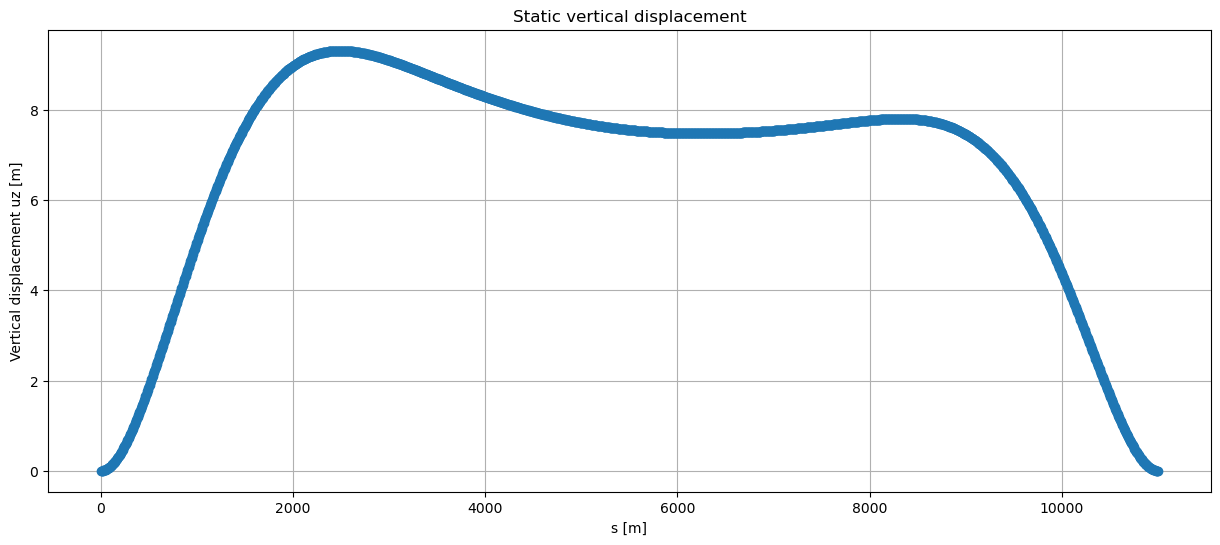

In [25]:
uz = uz[2::LDOF]

plt.figure()
plt.plot(s, uz, "-o")
plt.xlabel("s [m]")
plt.ylabel("Vertical displacement uz [m]")
plt.title("Static vertical displacement")
plt.grid()
plt.show()

## Horizontal Displacement

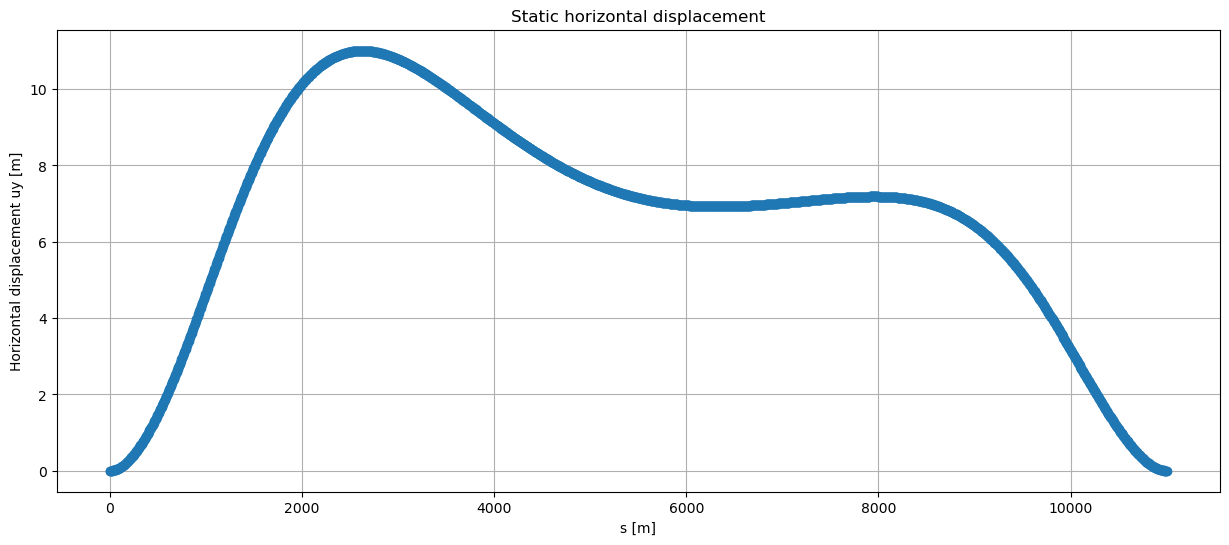

In [26]:
uy = uy[1::LDOF]

plt.figure()
plt.plot(s, uy, "-o")
plt.xlabel("s [m]")
plt.ylabel("Horizontal displacement uy [m]")
plt.title("Static horizontal displacement")
plt.grid()
plt.show()


# Dynamic modelling

## Dynamic Forcing

In [ ]:

F_static = (Fy + Fz).copy()

dt = 0.4
T_total = 500
t = np.arange(0, T_total + dt, dt)
n_steps = len(t)

Tp = 6.75
h = 44

H_wave = 2.4

n_dof = nDof

dfy = pd.read_csv("interpolated_horizontal_stiffness_data2.csv")
dfz = pd.read_csv("interpolated_vertical_stiffness_data2.csv")

ky_lin = LinearNDInterpolator(list(zip(dfy["water_depth_m"], dfy["u_mid_m"])), dfy["Ky_N_per_m"])
ky_near = NearestNDInterpolator(list(zip(dfy["water_depth_m"], dfy["u_mid_m"])), dfy["Ky_N_per_m"])

kz_lin = LinearNDInterpolator(list(zip(dfz["water_depth_m"], dfz["u_mid_m"])), dfz["Kz_N_per_m"])
kz_near = NearestNDInterpolator(list(zip(dfz["water_depth_m"], dfz["u_mid_m"])), dfz["Kz_N_per_m"])

def safe_interp(lin, near, h, u):
    val = lin(h, u)
    if np.isnan(val):
        val = near(h, u)
    return float(val)

depth_nodes = np.linspace(160, 275, len(mooring_nodes))


def airy_wave_properties(T, h, g=9.81):

    omega = 2*np.pi/T

    def residual(k):
        return g*k*np.tanh(k*h) - omega**2

    k0 = omega**2/g
    k = fsolve(residual, k0)[0]

    L = 2*np.pi/k
    c = omega/k

    return omega, k, L, c


omega, k, L, c = airy_wave_properties(Tp, h)


def airy_horizontal_velocity(z, x, t, H, T, h, g=9.81):

    a = H / 2
    omega, k, _, _ = airy_wave_properties(T, h, g)

    return (
        a * omega
        * np.cosh(k * (z + h)) / np.sinh(k * h)
        * np.cos(k*x - omega*t)
    )


def airy_horizontal_acceleration(z, x, t, H, T, h, g=9.81):

    a = H / 2
    omega, k, _, _ = airy_wave_properties(T, h, g)

    return (
        a * omega**2
        * np.cosh(k * (z + h)) / np.sinh(k * h)
        * np.sin(k*x - omega*t)
    )


def morison_force_yz_per_length(
    z, x, t, H, T, h, D,
    Cd_y, Cm_y, Cd_z, Cm_z,
    rho=1027, g=9.81
):

    uy = airy_horizontal_velocity(z, x, t, H, T, h, g)
    ay = airy_horizontal_acceleration(z, x, t, H, T, h, g)

    a = H / 2
    omega, k, _, _ = airy_wave_properties(T, h, g)

    uz = (
        a * omega
        * np.sinh(k * (z + h)) / np.sinh(k * h)
        * np.sin(k*x - omega*t)
    )

    az = (
        -a * omega**2
        * np.sinh(k * (z + h)) / np.sinh(k * h)
        * np.cos(k*x - omega*t)
    )

    qy = (
        0.5 * rho * Cd_y * D * abs(uy) * (uy + 0.8)
        + rho * Cm_y * (np.pi * D**2 / 4) * ay
    )

    qz = (
        0.5 * rho * Cd_z * D * abs(uz) * uz
        + rho * Cm_z * (np.pi * D**2 / 4) * az
    )

    return qy, qz



F_time = np.zeros((n_steps, nDof))

D = 12.7

Cd_y = 0.7
Cm_y = Cm

Cd_z = 0.7
Cm_z = Cm

for n, tn in enumerate(t):

    Fdyn = np.zeros(nDof)

    for iEle in range(nEle):

        n1 = int(Ele_tunnel[iEle][0])
        n2 = int(Ele_tunnel[iEle][1])

        x1, z1 = NodeC[n1][0], NodeC[n1][2]
        x2, z2 = NodeC[n2][0], NodeC[n2][2]

        Le = np.linalg.norm(np.asarray(NodeC[n2]) - np.asarray(NodeC[n1]))

        qy1, qz1 = morison_force_yz_per_length(
            z1, x1, tn, H_wave, Tp, h,
            D, Cd_y, Cm_y, Cd_z, Cm_z
        )

        qy2, qz2 = morison_force_yz_per_length(
            z2, x2, tn, H_wave, Tp, h,
            D, Cd_y, Cm_y, Cd_z, Cm_z
        )

        Fdyn[n1*LDOF + 1] += Le / 6 * (2*qy1 + qy2)
        Fdyn[n2*LDOF + 1] += Le / 6 * (qy1 + 2*qy2)

        Fdyn[n1*LDOF + 2] += Le / 6 * (2*qz1 + qz2)
        Fdyn[n2*LDOF + 2] += Le / 6 * (qz1 + 2*qz2)

    F_time[n, :] = Fdyn


In [ ]:
from scipy.linalg import cho_factor, cho_solve
rho = 1027
g = 9.81
Ele_arr = np.asarray(Ele_tunnel, dtype=int)
ele_n1 = Ele_arr[:, 0]
ele_n2 = Ele_arr[:, 1]

NodeC_arr = np.asarray(NodeC)

x1 = NodeC_arr[ele_n1, 0]
x2 = NodeC_arr[ele_n2, 0]
z1 = NodeC_arr[ele_n1, 2]
z2 = NodeC_arr[ele_n2, 2]

Le = np.linalg.norm(NodeC_arr[ele_n2] - NodeC_arr[ele_n1], axis=1)


a_wave = H_wave / 2
omega, k, L, c = airy_wave_properties(Tp, h)

sinh_kh = np.sinh(k*h)

cosh1 = np.cosh(k*(z1 + h)) / sinh_kh
cosh2 = np.cosh(k*(z2 + h)) / sinh_kh

sinh1 = np.sinh(k*(z1 + h)) / sinh_kh
sinh2 = np.sinh(k*(z2 + h)) / sinh_kh

A_morison = np.pi * D**2 / 4


def assemble_wave_force_free_fast(tn):
    """
    Assemble wave force directly on free DOFs.
    No full F_time array is stored.
    """

    phase1 = k*x1 - omega*tn
    phase2 = k*x2 - omega*tn

    uy1 = a_wave * omega * cosh1 * np.cos(phase1)
    uy2 = a_wave * omega * cosh2 * np.cos(phase2)

    ay1 = a_wave * omega**2 * cosh1 * np.sin(phase1)
    ay2 = a_wave * omega**2 * cosh2 * np.sin(phase2)

    uz1 = a_wave * omega * sinh1 * np.sin(phase1)
    uz2 = a_wave * omega * sinh2 * np.sin(phase2)

    az1 = -a_wave * omega**2 * sinh1 * np.cos(phase1)
    az2 = -a_wave * omega**2 * sinh2 * np.cos(phase2)

    qy1 = 0.5*rho*Cd_y*D*np.abs(uy1)*(uy1 + 0.8) + rho*Cm_y*A_morison*ay1
    qy2 = 0.5*rho*Cd_y*D*np.abs(uy2)*(uy2 + 0.8) + rho*Cm_y*A_morison*ay2

    qz1 = 0.5*rho*Cd_z*D*np.abs(uz1)*uz1 + rho*Cm_z*A_morison*az1
    qz2 = 0.5*rho*Cd_z*D*np.abs(uz2)*uz2 + rho*Cm_z*A_morison*az2

    Fdyn = np.zeros(nDof)

    np.add.at(Fdyn, ele_n1*LDOF + 1, Le/6 * (2*qy1 + qy2))
    np.add.at(Fdyn, ele_n2*LDOF + 1, Le/6 * (qy1 + 2*qy2))

    np.add.at(Fdyn, ele_n1*LDOF + 2, Le/6 * (2*qz1 + qz2))
    np.add.at(Fdyn, ele_n2*LDOF + 2, Le/6 * (qz1 + 2*qz2))

    return Fdyn[DofsF]

In [ ]:
free_dof_map = {gdof: i for i, gdof in enumerate(DofsF)}

u_max_y = dfy["u_mid_m"].max()
u_max_z = dfz["u_mid_m"].max()

depth_nodes = np.linspace(160, 275, len(mooring_nodes))

In [ ]:
beta = 1/4
gamma = 1/2

n_free = len(DofsF)

U_hist = np.zeros((n_steps, n_free))


response_dofs = {
    "quarter_uy": free_dof_map[int(0.25*(nNodes-1))*LDOF + 1],
    "quarter_uz": free_dof_map[int(0.25*(nNodes-1))*LDOF + 2],
    "midspan_uy": free_dof_map[int(0.50*(nNodes-1))*LDOF + 1],
    "midspan_uz": free_dof_map[int(0.50*(nNodes-1))*LDOF + 2],
    "threequarter_uy": free_dof_map[int(0.75*(nNodes-1))*LDOF + 1],
    "threequarter_uz": free_dof_map[int(0.75*(nNodes-1))*LDOF + 2],
}

V_key = {key: np.zeros(n_steps) for key in response_dofs}
A_key = {key: np.zeros(n_steps) for key in response_dofs}

F_static_F = F_static[DofsF]
K_static = K_FF.copy()
u = np.linalg.solve(K_static, F_static_F)
v = np.zeros(n_free)
a = np.zeros(n_free)
alpha_R = 0.01
beta_R  = 1e-4
for n, tn in enumerate(t):

    K_nl = K_FF.copy()

    for i, node in enumerate(mooring_nodes):

        h_node = depth_nodes[i]

        global_dof_y = node*LDOF + 1
        global_dof_z = node*LDOF + 2

        if global_dof_y in free_dof_map:
            local_dof_y = free_dof_map[global_dof_y]
            uy_abs = np.clip(abs(u[local_dof_y]), 0.0, u_max_y)
            ky = safe_interp(ky_lin, ky_near, h_node, uy_abs)
            K_nl[local_dof_y, local_dof_y] += ky

        if global_dof_z in free_dof_map:
            local_dof_z = free_dof_map[global_dof_z]
            uz_abs = np.clip(abs(u[local_dof_z]), 0.0, u_max_z)
            kz = safe_interp(kz_lin, kz_near, h_node, uz_abs)
            K_nl[local_dof_z, local_dof_z] += kz

    C_nl = alpha_R * M_FF + beta_R * K_nl

    K_eff = (
        K_nl
        + gamma/(beta*dt)*C_nl
        + 1/(beta*dt**2)*M_FF
    )

    F_ext_F = F_static_F + assemble_wave_force_free_fast(tn)

    F_eff = (
        F_ext_F
        + M_FF @ (
            1/(beta*dt**2)*u
            + 1/(beta*dt)*v
            + (1/(2*beta) - 1)*a
        )
        + C_nl @ (
            gamma/(beta*dt)*u
            + (gamma/beta - 1)*v
            + dt*(gamma/(2*beta) - 1)*a
        )
    )

    cf = cho_factor(K_eff, check_finite=False)
    u_new = cho_solve(cf, F_eff, check_finite=False)

    a_new = (
        1/(beta*dt**2)*(u_new - u)
        - 1/(beta*dt)*v
        - (1/(2*beta) - 1)*a
    )

    v_new = v + dt*((1 - gamma)*a + gamma*a_new)

    U_hist[n, :] = u_new
    for key, idx in response_dofs.items():
        V_key[key][n] = v_new[idx]
        A_key[key][n] = a_new[idx]
    

    u = u_new
    v = v_new
    a = a_new

U_full = np.zeros((n_steps, nDof))
U_full[:, DofsF] = U_hist
# V_full = np.zeros((n_steps, nDof))
# V_full[:, DofsF] = V_hist
# A_full = np.zeros((n_steps, nDof))
# A_full[:, DofsF] =A_hist

In [48]:
np.savez_compressed(
    "dynamic_response_results.npz",
    t=t,
    U_hist=U_hist,
    U_full=U_full,
    V_key=V_key,
    A_key=A_key,
    response_dofs=response_dofs
)

In [ ]:
import pandas as pd

U_key = {}
for key, local_idx in response_dofs.items():
    U_key[key] = U_hist[:, local_idx]

df_key = pd.DataFrame({"time": t})

for key in response_dofs:
    df_key[f"{key}_disp"] = U_key[key]
    df_key[f"{key}_vel"]  = V_key[key]
    df_key[f"{key}_acc"]  = A_key[key]

df_key.to_csv("key_response_locations.csv", index=False)

In [75]:
Phi_test = vr[:, :10]
print(Phi_test.T @ M_FF @ Phi_test)

[[ 1.00000000e+00  2.50012447e-15  1.15140915e-15 -1.92771146e-16
  -5.46376273e-16 -6.47504278e-17 -1.07120583e-15  3.13330669e-16
  -1.44995100e-16 -4.73254248e-17]
 [ 2.55003419e-15  1.00000000e+00  3.79785857e-15  1.51177424e-15
   1.49626250e-15  1.80902812e-15 -1.51664426e-15 -4.70221738e-17
  -6.17539535e-16 -3.58176352e-16]
 [ 1.13627098e-15  3.78418068e-15  1.00000000e+00 -1.21772167e-15
  -2.48471429e-15 -4.65980353e-16 -1.83217906e-15 -2.96036850e-16
  -4.76676261e-16 -2.29471390e-16]
 [-1.91239711e-16  1.54116628e-15 -1.26876049e-15  1.00000000e+00
  -4.29179334e-15  2.31925668e-16 -1.03440320e-15 -7.85519297e-17
  -9.16150836e-18 -1.49435585e-15]
 [-5.46559338e-16  1.49669732e-15 -2.48424377e-15 -4.29217450e-15
   1.00000000e+00  4.25424669e-15 -2.09489544e-15  8.70848126e-16
  -9.55531833e-16  6.35511033e-16]
 [-6.45225759e-17  1.80969558e-15 -4.65553554e-16  2.32559990e-16
   4.23038069e-15  1.00000000e+00 -2.84993383e-15 -5.46688617e-16
   1.95165391e-16 -4.56125125e-16

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from scipy.linalg import solve

rom_mode_counts = [10, 20, 50, 100, 1000]

n_available_modes = vr.shape[1]
print(f"Available modes in vr: {n_available_modes}")

mid_node = int(0.50 * (nNodes - 1))
mid_dof_y_global = mid_node * LDOF + 1
mid_dof_z_global = mid_node * LDOF + 2

mid_dof_y = free_dof_map[mid_dof_y_global]
mid_dof_z = free_dof_map[mid_dof_z_global]

uy_full = U_full[:, mid_dof_y_global]
uz_full = U_full[:, mid_dof_z_global]

rom_results = {}
rom_summary = []
idx = np.argsort(w)          

w_sorted = w[idx]
vr_sorted = vr[:, idx]

freqs_sorted = np.sqrt(w_sorted) / (2*np.pi)

vr = vr_sorted
print(freqs_sorted[:10])

for mode_idx, n_modes_requested in enumerate(rom_mode_counts):

    n_modes_rom = min(n_modes_requested, n_available_modes)

    if n_modes_rom < n_modes_requested:
        print(
            f"\nRequested {n_modes_requested} modes, "
            f"but only {n_available_modes} are available. "
            f"Using {n_modes_rom} modes instead."
        )

    print(
        f"\n========== ROM {mode_idx+1}/{len(rom_mode_counts)} "
        f"({n_modes_rom} modes) =========="
    )

    rom_start = time.time()

    Phi = vr[:, :n_modes_rom]

    M_r = Phi.T @ M_FF @ Phi
    K_r = Phi.T @ K_FF @ Phi
    C_r = alpha_R * M_r + beta_R * K_r

    q_static = solve(K_r, Phi.T @ F_static_F)
    q = np.zeros(n_modes_rom)
    qdot = np.zeros(n_modes_rom)

    F0_r = Phi.T @ assemble_wave_force_free_fast(t[0])
    qddot = solve(M_r, F0_r - C_r @ qdot - K_r @ q)
    beta = 1/4
    gamma = 1/2

    K_eff_r = (
        K_r
        + gamma/(beta*dt) * C_r
        + 1/(beta*dt**2) * M_r
    )

    q_hist = np.zeros((n_steps, n_modes_rom))
    uy_rom = np.zeros(n_steps)
    uz_rom = np.zeros(n_steps)

    for i, ti in enumerate(t):

        if i % 100 == 0 and i > 0:
            elapsed = time.time() - rom_start
            avg_time = elapsed / i
            remaining_steps = n_steps - i
            eta = avg_time * remaining_steps

            print(
                f"Modes={n_modes_rom:3d} | "
                f"Step {i:5d}/{n_steps} "
                f"({100*i/n_steps:5.1f}%) | "
                f"Elapsed={elapsed/60:6.1f} min | "
                f"ETA={eta/60:6.1f} min"
            )

        F_ext = assemble_wave_force_free_fast(ti)
        F_r = Phi.T @ F_ext

        F_eff_r = (
            F_r
            + M_r @ (
                1/(beta*dt**2)*q
                + 1/(beta*dt)*qdot
                + (1/(2*beta) - 1)*qddot
            )
            + C_r @ (
                gamma/(beta*dt)*q
                + (gamma/beta - 1)*qdot
                + dt*(gamma/(2*beta) - 1)*qddot
            )
        )

        q_new = solve(K_eff_r, F_eff_r)

        qddot_new = (
            1/(beta*dt**2)*(q_new - q)
            - 1/(beta*dt)*qdot
            - (1/(2*beta) - 1)*qddot
        )

        qdot_new = qdot + dt*((1 - gamma)*qddot + gamma*qddot_new)

        uy_rom[i] = Phi[mid_dof_y, :] @ (q_static + q_new)
        uz_rom[i] = Phi[mid_dof_z, :] @ (q_static + q_new)

        q_hist[i, :] = q_new

        q = q_new
        qdot = qdot_new
        qddot = qddot_new

    rom_results[n_modes_rom] = {
        "uy": uy_rom,
        "uz": uz_rom,
        "q_hist": q_hist,
    }

    rom_elapsed = time.time() - rom_start

    print(
        f"Finished ROM with {n_modes_rom} modes "
        f"in {rom_elapsed/60:.2f} min"
    )

    err_uy = (
        np.max(np.abs(uy_rom - uy_full))
        / max(np.max(np.abs(uy_full)), 1e-30)
        * 100
    )

    err_uz = (
        np.max(np.abs(uz_rom - uz_full))
        / max(np.max(np.abs(uz_full)), 1e-30)
        * 100
    )

    rom_summary.append({
        "Requested modes": n_modes_requested,
        "Used modes": n_modes_rom,
        "Max error uy [%]": err_uy,
        "Max error uz [%]": err_uz,
        "Max uy ROM [m]": np.max(np.abs(uy_rom)),
        "Max uz ROM [m]": np.max(np.abs(uz_rom)),
        "Runtime [min]": rom_elapsed/60,
    })

df_rom = pd.DataFrame(rom_summary)
display(df_rom)

Available modes in vr: 1000
[0.00736724 0.00743722 0.00776273 0.0078387  0.00786962 0.0078864
 0.00816596 0.00819267 0.00827368 0.00837636]

========== ROM 1/5 (10 modes) ==========
Modes= 10 | Step   100/1251 (  8.0%) | Elapsed=   0.0 min | ETA=   0.1 min
Modes= 10 | Step   200/1251 ( 16.0%) | Elapsed=   0.0 min | ETA=   0.0 min
Modes= 10 | Step   300/1251 ( 24.0%) | Elapsed=   0.0 min | ETA=   0.0 min
Modes= 10 | Step   400/1251 ( 32.0%) | Elapsed=   0.0 min | ETA=   0.0 min
Modes= 10 | Step   500/1251 ( 40.0%) | Elapsed=   0.0 min | ETA=   0.0 min
Modes= 10 | Step   600/1251 ( 48.0%) | Elapsed=   0.0 min | ETA=   0.0 min
Modes= 10 | Step   700/1251 ( 56.0%) | Elapsed=   0.0 min | ETA=   0.0 min
Modes= 10 | Step   800/1251 ( 63.9%) | Elapsed=   0.0 min | ETA=   0.0 min
Modes= 10 | Step   900/1251 ( 71.9%) | Elapsed=   0.0 min | ETA=   0.0 min
Modes= 10 | Step  1000/1251 ( 79.9%) | Elapsed=   0.0 min | ETA=   0.0 min
Modes= 10 | Step  1100/1251 ( 87.9%) | Elapsed=   0.0 min | ETA=   0

,Requested modes,Used modes,Max error uy [%],Max error uz [%],Max uy ROM [m],Max uz ROM [m],Runtime [min]
0,10,10,132.847594,93.171378,2.482673,0.515884,0.025031
1,20,20,133.919661,128.456108,2.565972,2.149792,0.026620
2,50,50,107.107182,127.055432,0.507251,2.043981,0.039722
3,100,100,197.136263,83.125817,9.352164,7.505847,0.045568
4,1000,1000,197.498524,83.754791,9.378206,7.553365,0.865732


In [77]:
print("f_100  =", freqs_sorted[99])
print("f_1000 =", freqs_sorted[999])

f_100  = 0.01920463322165123
f_1000 = 0.05920103545569887


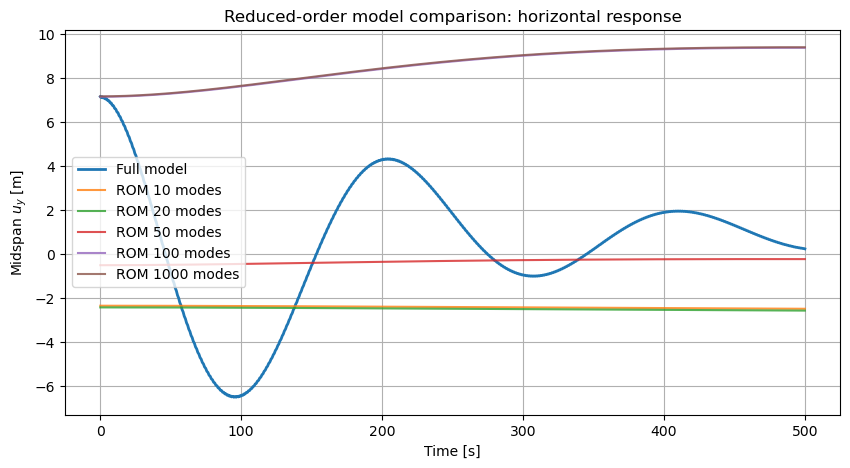

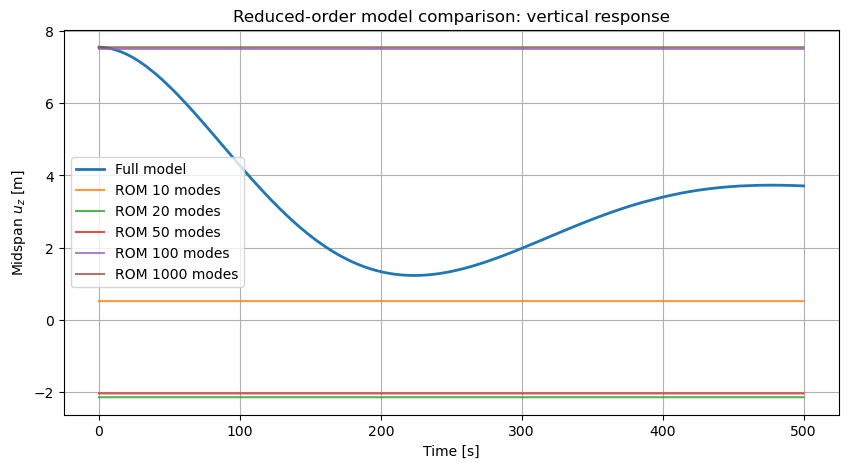

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(t, uy_full, label="Full model", linewidth=2)

for n_modes_rom in rom_mode_counts:
    plt.plot(
        t,
        rom_results[n_modes_rom]["uy"],
        label=f"ROM {n_modes_rom} modes",
        alpha=0.8
    )

plt.xlabel("Time [s]")
plt.ylabel(r"Midspan $u_y$ [m]")
plt.title("Reduced-order model comparison: horizontal response")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10,5))
plt.plot(t, uz_full, label="Full model", linewidth=2)

for n_modes_rom in rom_mode_counts:
    plt.plot(
        t,
        rom_results[n_modes_rom]["uz"],
        label=f"ROM {n_modes_rom} modes",
        alpha=0.8
    )

plt.xlabel("Time [s]")
plt.ylabel(r"Midspan $u_z$ [m]")
plt.title("Reduced-order model comparison: vertical response")
plt.grid(True)
plt.legend()
plt.show()

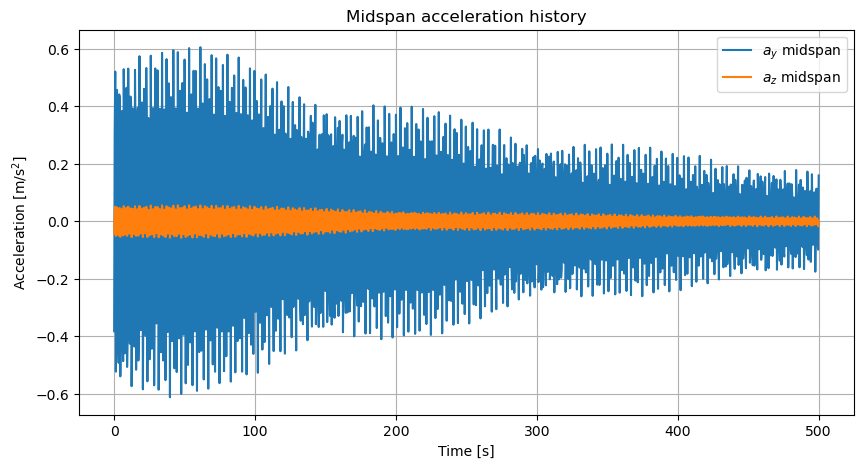

In [32]:
plt.figure(figsize=(10,5))
plt.plot(t, A_key["midspan_uy"], label=r"$a_y$ midspan")
plt.plot(t, A_key["midspan_uz"], label=r"$a_z$ midspan")
plt.xlabel("Time [s]")
plt.ylabel("Acceleration [m/s$^2$]")
plt.title("Midspan acceleration history")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:

def beam3d_local_stiffness(EA, EIy, EIz, GJ, L):
    k = np.zeros((12, 12))

    k[0, 0] = k[6, 6] = EA / L
    k[0, 6] = k[6, 0] = -EA / L

    k[3, 3] = k[9, 9] = GJ / L
    k[3, 9] = k[9, 3] = -GJ / L

    c1, c2, c3, c4 = 12*EIz/L**3, 6*EIz/L**2, 4*EIz/L, 2*EIz/L
    dofs = [1, 5, 7, 11]
    kb = np.array([
        [ c1,  c2, -c1,  c2],
        [ c2,  c3, -c2,  c4],
        [-c1, -c2,  c1, -c2],
        [ c2,  c4, -c2,  c3],
    ])
    for i in range(4):
        for j in range(4):
            k[dofs[i], dofs[j]] += kb[i, j]

    c1, c2, c3, c4 = 12*EIy/L**3, 6*EIy/L**2, 4*EIy/L, 2*EIy/L
    dofs = [2, 4, 8, 10]
    kb = np.array([
        [ c1, -c2, -c1, -c2],
        [-c2,  c3,  c2,  c4],
        [-c1,  c2,  c1,  c2],
        [-c2,  c4,  c2,  c3],
    ])
    for i in range(4):
        for j in range(4):
            k[dofs[i], dofs[j]] += kb[i, j]

    return k


def element_dofs(n1, n2):
    return np.r_[
        np.arange(n1*LDOF, n1*LDOF + LDOF),
        np.arange(n2*LDOF, n2*LDOF + LDOF)
    ]


n_elements = len(Ele_tunnel)

N_env  = np.zeros(n_elements)
Vy_env = np.zeros(n_elements)
Vz_env = np.zeros(n_elements)
Tx_env = np.zeros(n_elements)
My_env = np.zeros(n_elements)
Mz_env = np.zeros(n_elements)
x_mid  = np.zeros(n_elements)

for e, ele in enumerate(Ele_tunnel):

    n1 = int(ele[0])
    n2 = int(ele[1])

    L_e = np.linalg.norm(np.asarray(NodeC[n2]) - np.asarray(NodeC[n1]))
    x_mid[e] = 0.5 * (NodeC[n1][0] + NodeC[n2][0])

    try:
        _, _, m_e, EA_e, EIy_e, EIz_e, GJ_e, Im_e = ele
    except:
        EA_e  = Beam_EA
        EIy_e = Beam_EIy
        EIz_e = Beam_EIz
        GJ_e  = Beam_GJ

    k_e = beam3d_local_stiffness(EA_e, EIy_e, EIz_e, GJ_e, L_e)
    edofs = element_dofs(n1, n2)

    for n in range(n_steps):

        u_e = U_full[n, edofs]
        f_e = k_e @ u_e

        N_vals  = [f_e[0],  f_e[6]]
        Vy_vals = [f_e[1],  f_e[7]]
        Vz_vals = [f_e[2],  f_e[8]]
        Tx_vals = [f_e[3],  f_e[9]]
        My_vals = [f_e[4],  f_e[10]]
        Mz_vals = [f_e[5],  f_e[11]]

        N_env[e]  = max(N_env[e],  np.max(np.abs(N_vals)))
        Vy_env[e] = max(Vy_env[e], np.max(np.abs(Vy_vals)))
        Vz_env[e] = max(Vz_env[e], np.max(np.abs(Vz_vals)))
        Tx_env[e] = max(Tx_env[e], np.max(np.abs(Tx_vals)))
        My_env[e] = max(My_env[e], np.max(np.abs(My_vals)))
        Mz_env[e] = max(Mz_env[e], np.max(np.abs(Mz_vals)))


df_force_env = pd.DataFrame({
    "element": np.arange(n_elements),
    "x_mid [m]": x_mid,
    "N_env [N]": N_env,
    "Vy_env [N]": Vy_env,
    "Vz_env [N]": Vz_env,
    "Tx_env [Nm]": Tx_env,
    "My_env [Nm]": My_env,
    "Mz_env [Nm]": Mz_env,
})

display(df_force_env)

print("Maximum force/moment envelopes:")
display(pd.DataFrame({
    "quantity": ["N", "Vy", "Vz", "Tx", "My", "Mz"],
    "maximum": [
        df_force_env["N_env [N]"].max(),
        df_force_env["Vy_env [N]"].max(),
        df_force_env["Vz_env [N]"].max(),
        df_force_env["Tx_env [Nm]"].max(),
        df_force_env["My_env [Nm]"].max(),
        df_force_env["Mz_env [Nm]"].max(),
    ],
    "unit": ["N", "N", "N", "Nm", "Nm", "Nm"]
}))

,element,x_mid [m],N_env [N],Vy_env [N],Vz_env [N],Tx_env [Nm],My_env [Nm],Mz_env [Nm]
0,0,3.125,0.0,1.772448e+09,1.445072e+08,0.0,6.605674e+09,3.146264e+10
1,1,9.375,0.0,1.772713e+09,1.441505e+08,0.0,6.516845e+09,3.030330e+10
2,2,15.625,0.0,1.773351e+09,1.438107e+08,0.0,6.430836e+09,2.982374e+10
3,3,21.875,0.0,1.774194e+09,1.434929e+08,0.0,6.347168e+09,2.928289e+10
4,4,28.125,0.0,1.775024e+09,1.428858e+08,0.0,6.260906e+09,2.862714e+10
...,...,...,...,...,...,...,...,...
1755,1755,10971.875,0.0,1.137860e+09,1.213050e+08,0.0,5.704164e+09,1.433132e+10
1756,1756,10978.125,0.0,1.137240e+09,1.215914e+08,0.0,5.787635e+09,1.446170e+10
1757,1757,10984.375,0.0,1.136397e+09,1.216967e+08,0.0,5.872045e+09,1.471589e+10
1758,1758,10990.625,0.0,1.135547e+09,1.213629e+08,0.0,5.955720e+09,1.497576e+10


Maximum force/moment envelopes:


,quantity,maximum,unit
0,N,0.000000e+00,N
1,Vy,1.776112e+09,N
2,Vz,1.505076e+08,N
3,Tx,0.000000e+00,Nm
4,My,6.605674e+09,Nm
5,Mz,3.146264e+10,Nm


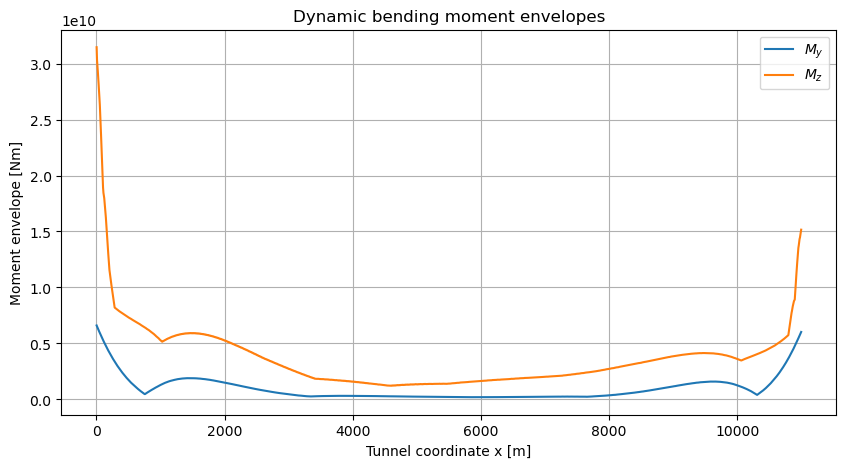

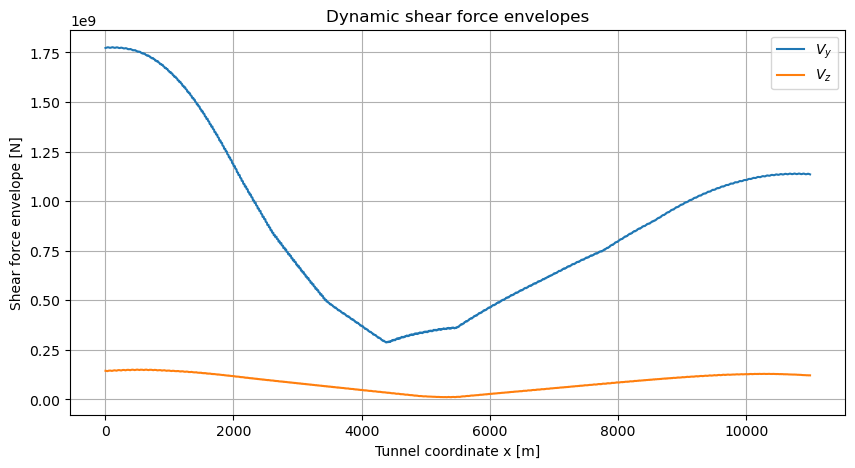

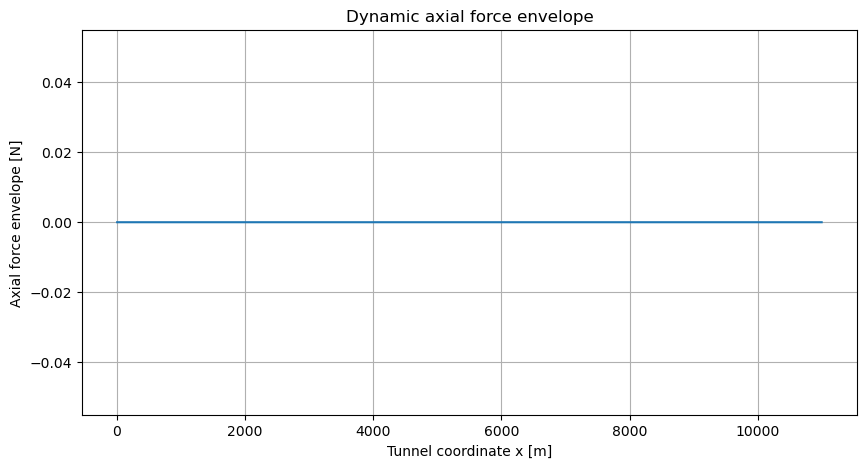

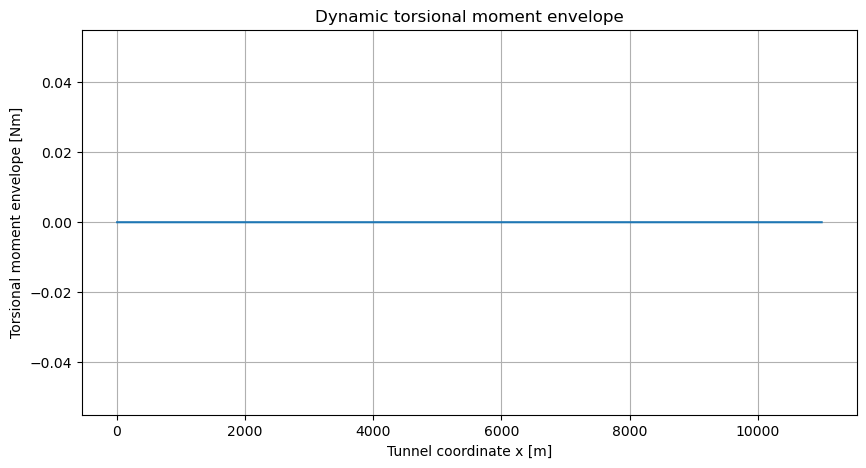

In [ ]:

plt.figure(figsize=(10,5))
plt.plot(df_force_env["x_mid [m]"], df_force_env["My_env [Nm]"], label=r"$M_y$")
plt.plot(df_force_env["x_mid [m]"], df_force_env["Mz_env [Nm]"], label=r"$M_z$")
plt.xlabel("Tunnel coordinate x [m]")
plt.ylabel("Moment envelope [Nm]")
plt.title("Dynamic bending moment envelopes")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df_force_env["x_mid [m]"], df_force_env["Vy_env [N]"], label=r"$V_y$")
plt.plot(df_force_env["x_mid [m]"], df_force_env["Vz_env [N]"], label=r"$V_z$")
plt.xlabel("Tunnel coordinate x [m]")
plt.ylabel("Shear force envelope [N]")
plt.title("Dynamic shear force envelopes")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df_force_env["x_mid [m]"], df_force_env["N_env [N]"])
plt.xlabel("Tunnel coordinate x [m]")
plt.ylabel("Axial force envelope [N]")
plt.title("Dynamic axial force envelope")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df_force_env["x_mid [m]"], df_force_env["Tx_env [Nm]"])
plt.xlabel("Tunnel coordinate x [m]")
plt.ylabel("Torsional moment envelope [Nm]")
plt.title("Dynamic torsional moment envelope")
plt.grid(True)
plt.show()

In [35]:


print(U_full)
print(np.max(np.abs(U_full[:, DofsF])))
print(U_full.shape)


[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   2.01509952e-06 -1.20171236e-06]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   1.98567799e-06 -9.97880374e-07]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   1.91836697e-06 -4.93511048e-07]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   1.35934118e-06 -2.97590876e-07]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   1.36023289e-06 -3.50794996e-07]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   1.36722704e-06 -4.32507344e-07]]
10.988757974756199
(1251, 10566)


### Displacement of the Tunnel per time step

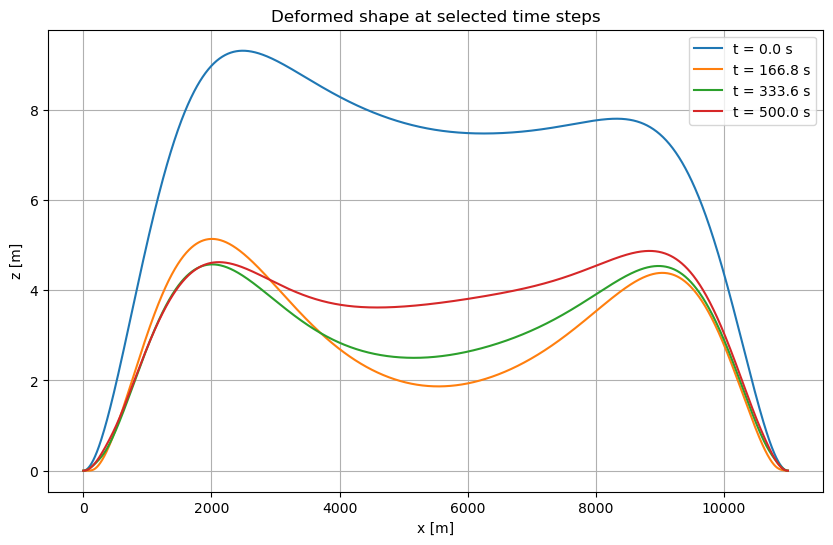

In [ ]:
plot_steps = [
    0,
    n_steps // 3,
    2 * n_steps // 3,
    n_steps - 1
]

plt.figure(figsize=(10, 6))

for n in plot_steps:

    scale = 1 

    y_def = []
    z_def = []

    for node in range(nNodes):

        y = NodeC[node][1]
        z = NodeC[node][2]

        uy = U_full[n, node*LDOF + 1]
        uz = U_full[n, node*LDOF + 2]

        y_def.append(y + scale * uy)
        z_def.append(z + scale * uz)

    plt.plot(
        s,
        z_def,
        label=f't = {t[n]:.1f} s'
    )

plt.xlabel('x [m]')
plt.ylabel('z [m]')
plt.title('Deformed shape at selected time steps')
plt.grid(True)
plt.legend()
plt.show()

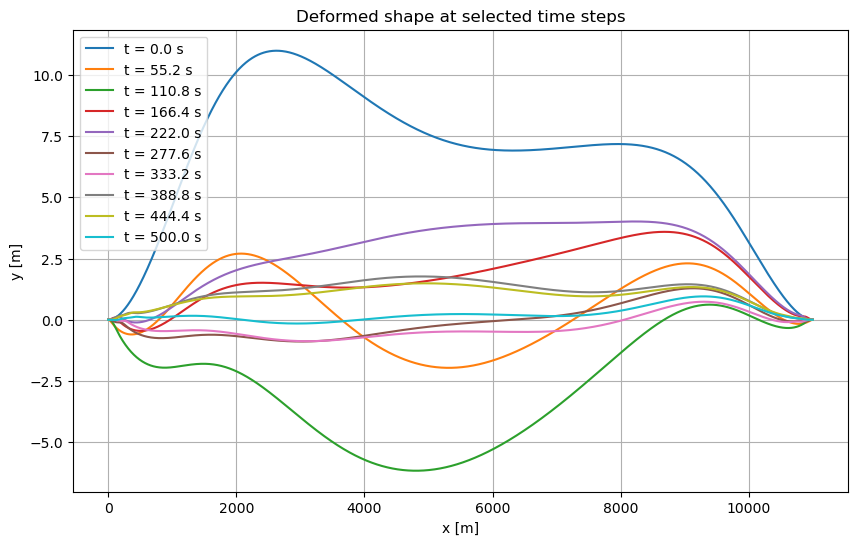

In [ ]:
plot_steps = np.linspace(0, n_steps - 1, 10, dtype=int)

plt.figure(figsize=(10, 6))

for n in plot_steps:

    scale = 1

    y_def = []
    z_def = []

    for node in range(nNodes):

        y = NodeC[node][1]
        z = NodeC[node][2]

        uy = U_full[n, node*LDOF + 1]
        uz = U_full[n, node*LDOF + 2]

        y_def.append(y + scale * uy)
        z_def.append(z + scale * uz)

    plt.plot(
        s,
        y_def,
        label=f't = {t[n]:.1f} s'
    )

plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Deformed shape at selected time steps')
plt.grid(True)
plt.legend()
plt.show()

## Displacement of A node 

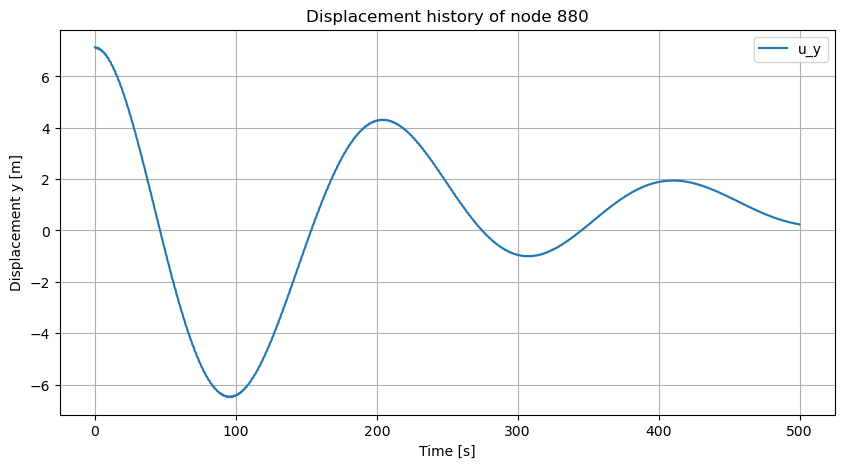

In [38]:
node = nNodes // 2

uy_hist = U_full[:, node*LDOF + 1]
uz_hist = U_full[:, node*LDOF + 2]

plt.figure(figsize=(10,5))
plt.plot(t, uy_hist, label='u_y')

plt.xlabel('Time [s]')
plt.ylabel('Displacement y [m]')
plt.title(f'Displacement history of node {node}')
plt.grid(True)
plt.legend()
plt.show()

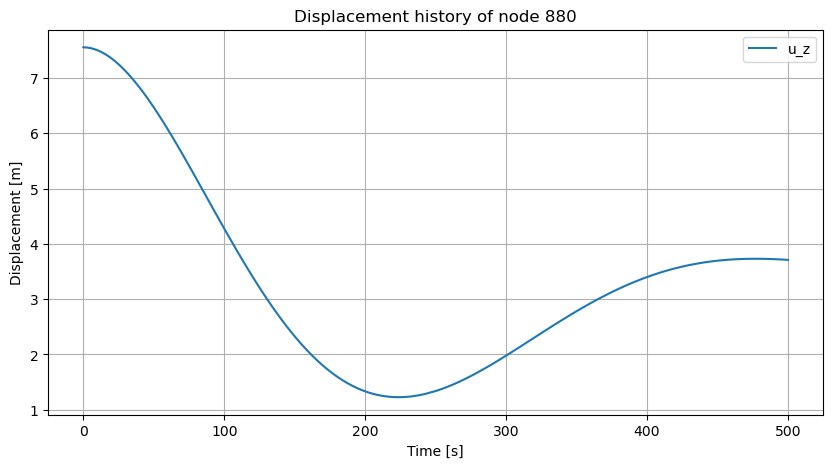

In [39]:
plt.figure(figsize=(10,5))
plt.plot(t, uz_hist, label='u_z')

plt.xlabel('Time [s]')
plt.ylabel('Displacement [m]')
plt.title(f'Displacement history of node {node}')
plt.grid(True)
plt.legend()
plt.show()

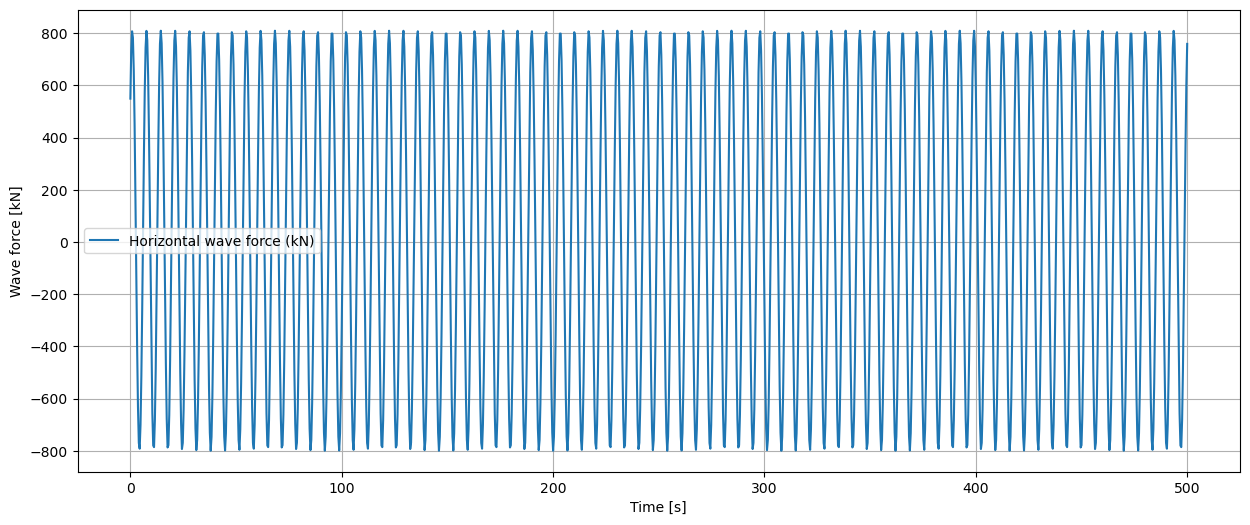

In [40]:
node_mid = len(NodeC)//2
dof = node_mid*LDOF + 1
dof2 = node_mid*LDOF + 2

plt.plot(t, F_time[:, dof]/1000, label='Horizontal wave force (kN)')
plt.xlabel("Time [s]")
plt.ylabel("Wave force [kN]")
plt.grid()
plt.legend()    
plt.show()

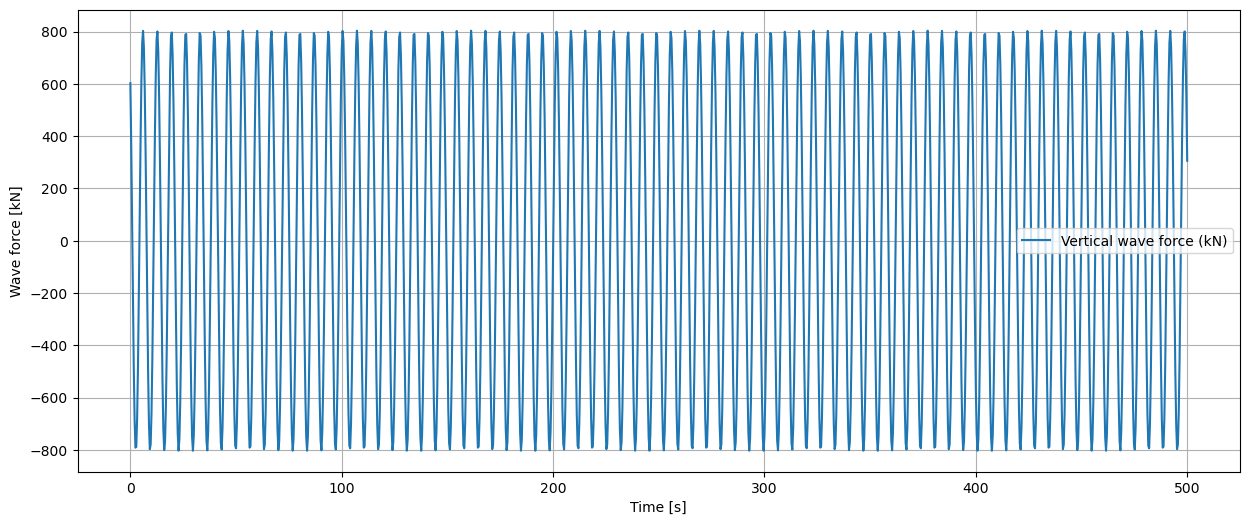

In [41]:
plt.plot(t, F_time[:, dof2]/1000, label='Vertical wave force (kN)')
plt.xlabel("Time [s]")
plt.ylabel("Wave force [kN]")
plt.grid()
plt.legend()    
plt.show()

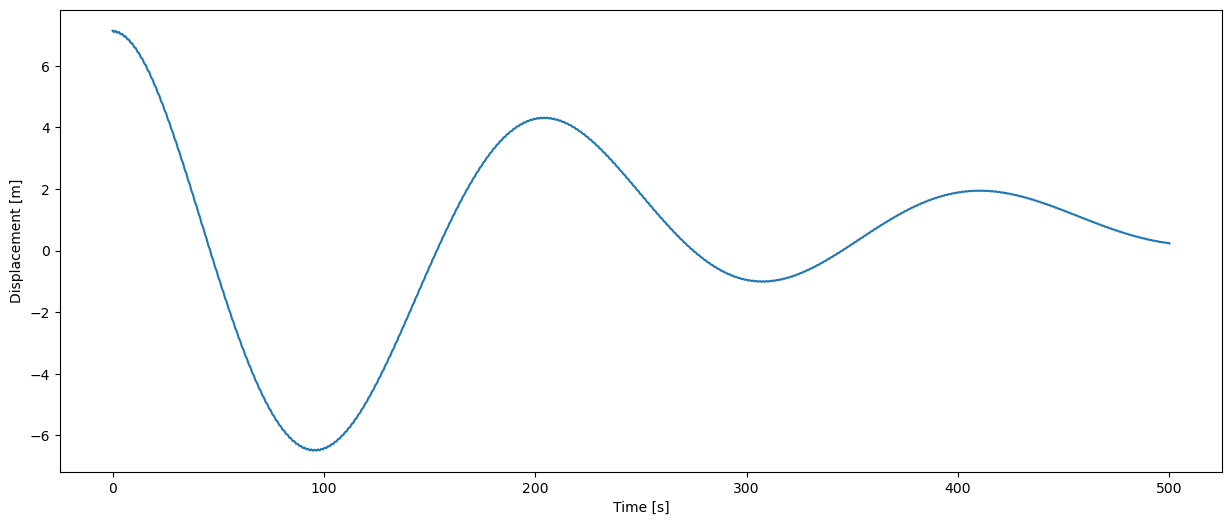

In [42]:
dof_y = node_mid*LDOF + 1

plt.plot(t, U_full[:, dof_y])
plt.xlabel('Time [s]')
plt.ylabel('Displacement [m]')
plt.show()


--------------------------------------------------
The maximum frequency is 1.2490 Hz
The frequency resolution is 0.0020 Hz
The dominant frequency is 0.0060 Hz
--------------------------------------------------
The maximum amplitude is 1.0184e+03 m


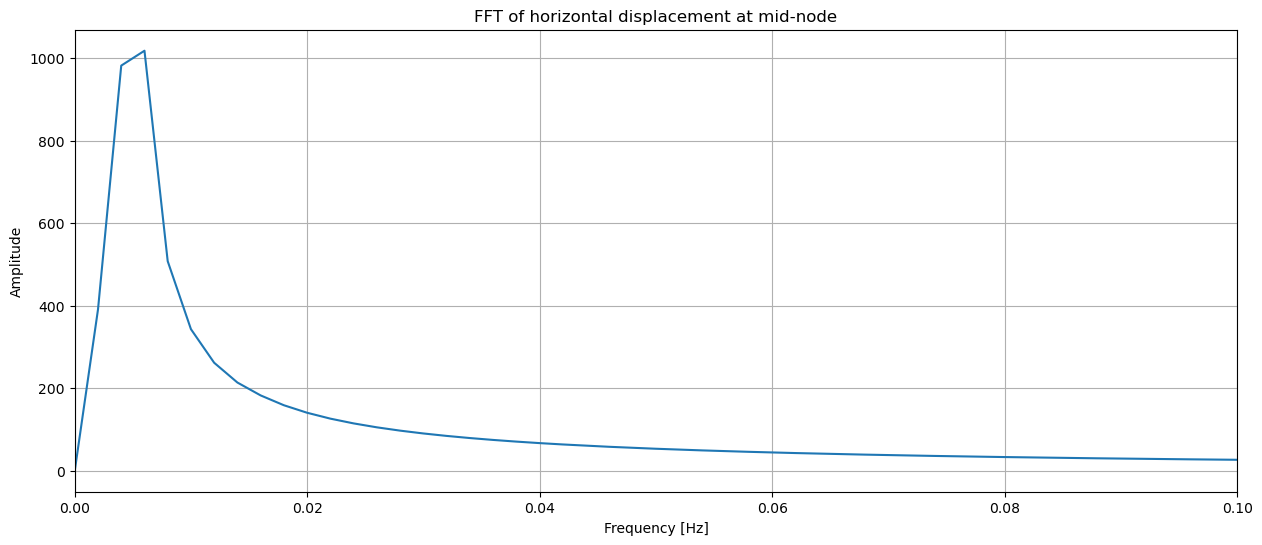

In [50]:
from scipy.fft import rfft, rfftfreq

sig = U_full[:, dof_y] - np.mean(U_full[:, dof_y])

freq = rfftfreq(len(sig), dt)
amp = np.abs(rfft(sig))

print("-" * 50)
print(f'The maximum frequency is {freq[-1]:.4f} Hz')
print(f'The frequency resolution is {freq[1]-freq[0]:.4f} Hz')
print(f'The dominant frequency is {freq[np.argmax(amp)]:.4f} Hz')
print("-" * 50)

print(f'The maximum amplitude is {np.max(amp):.4e} m')

plt.plot(freq, amp)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.title("FFT of horizontal displacement at mid-node")
plt.xlim(0, 0.1)
plt.grid()
plt.show()

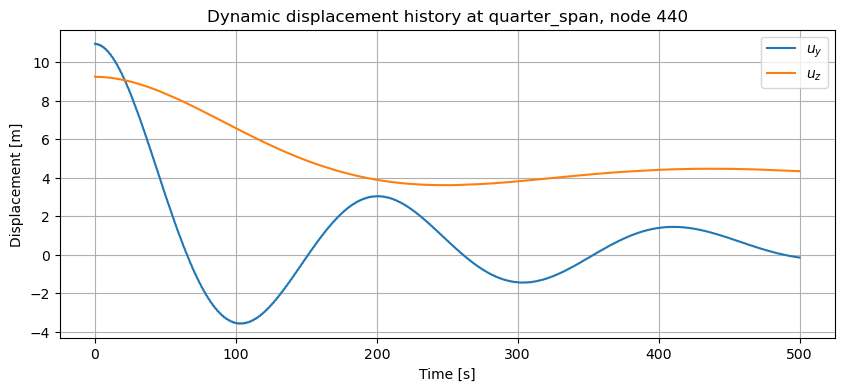

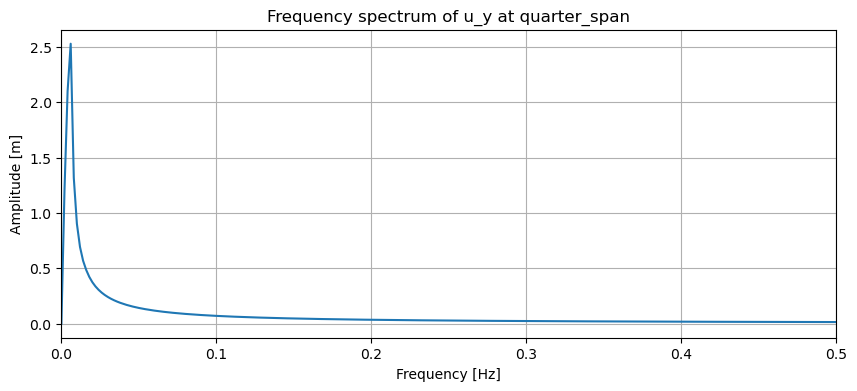

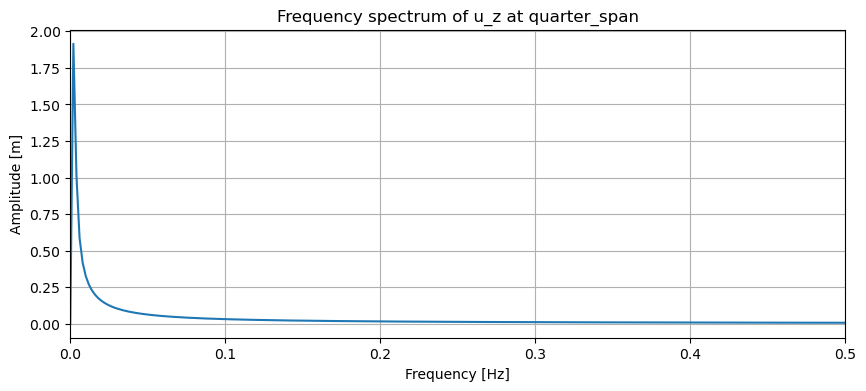

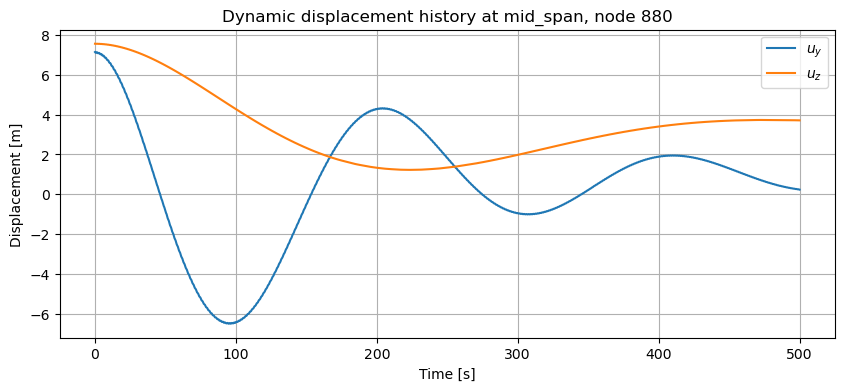

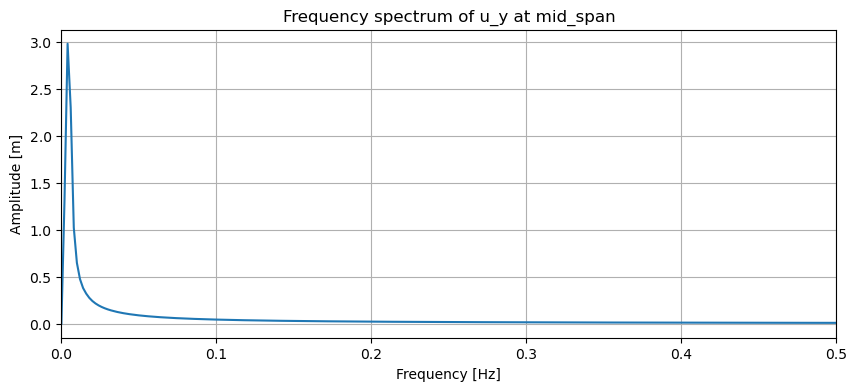

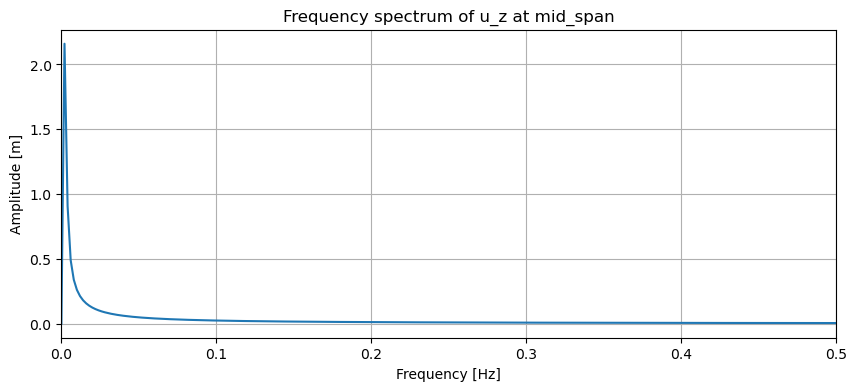

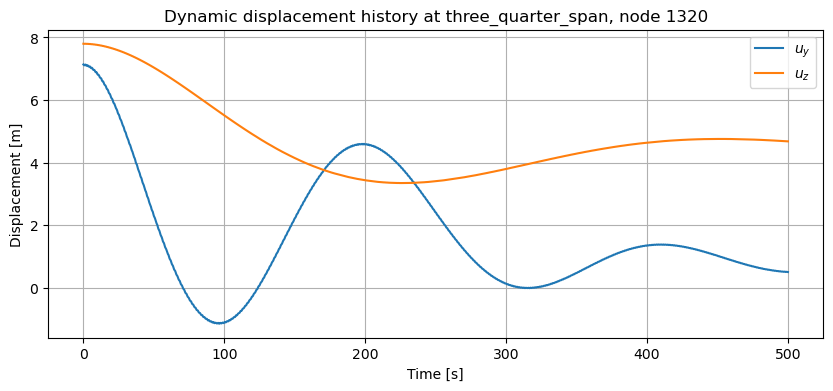

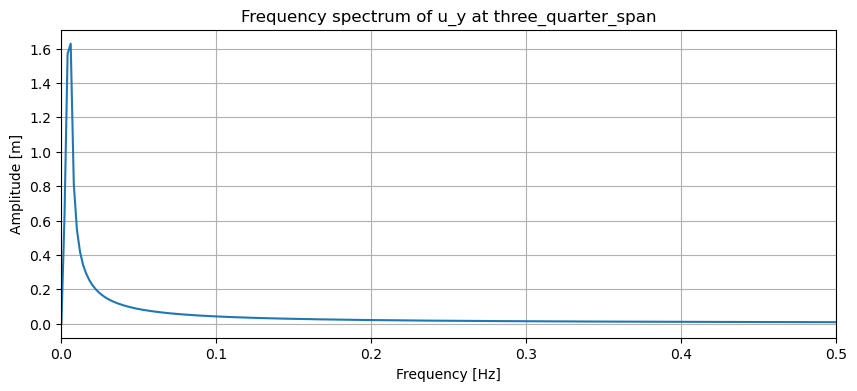

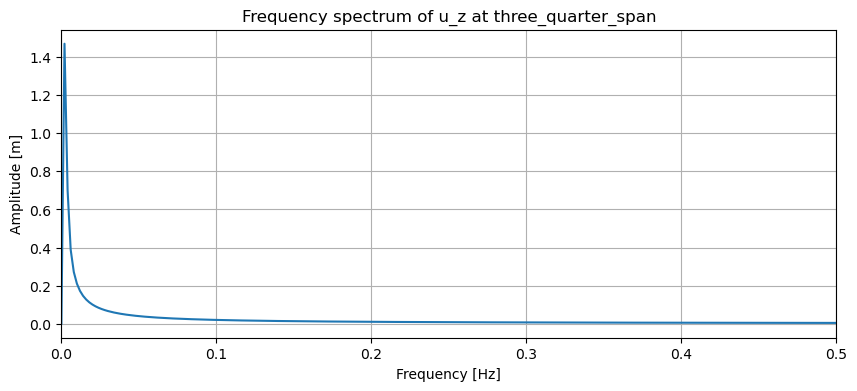

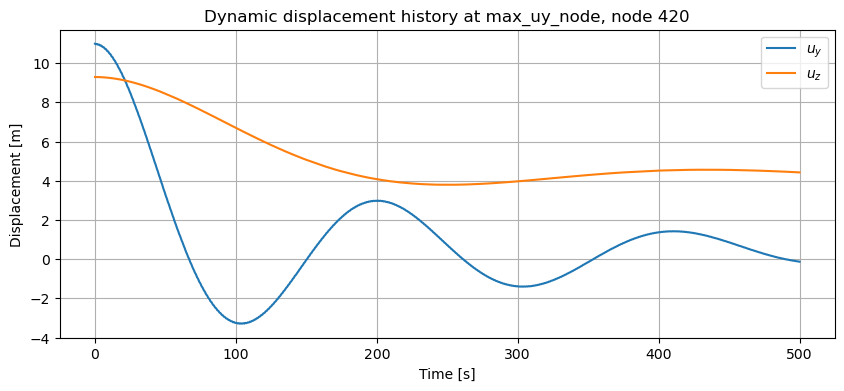

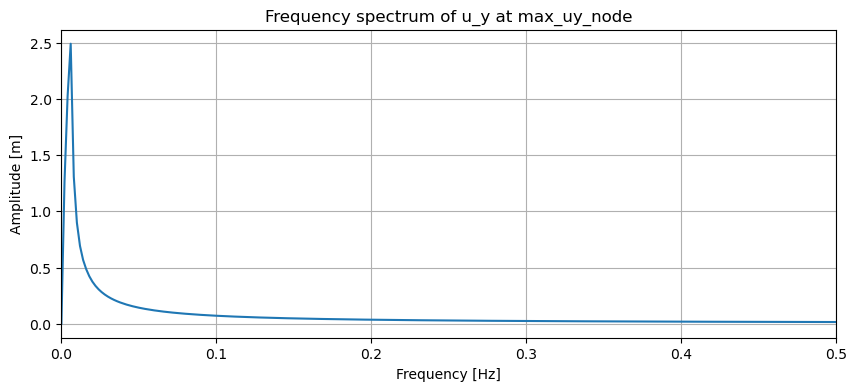

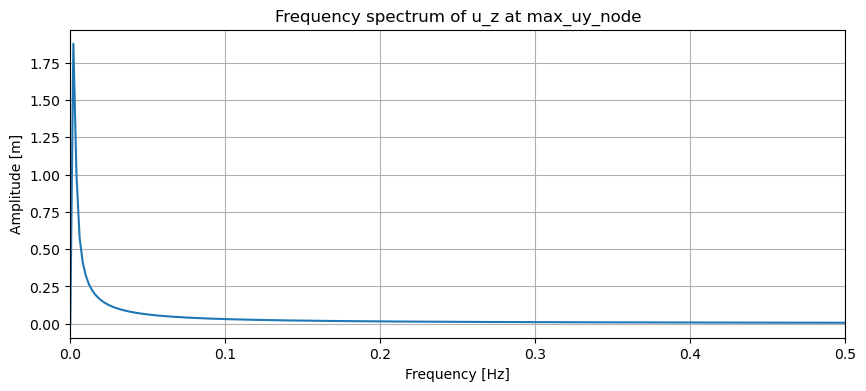

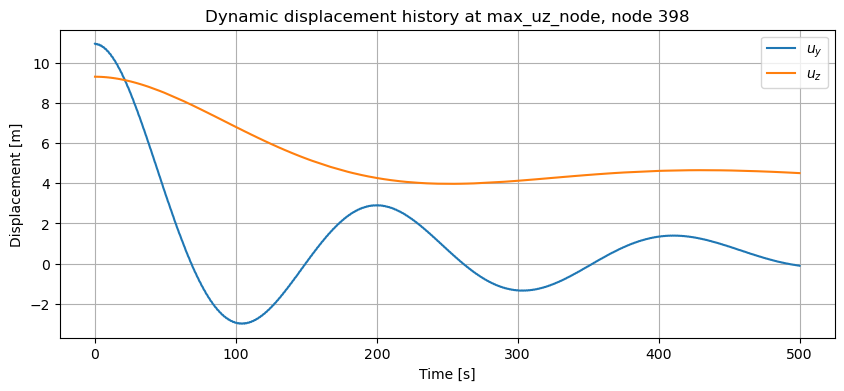

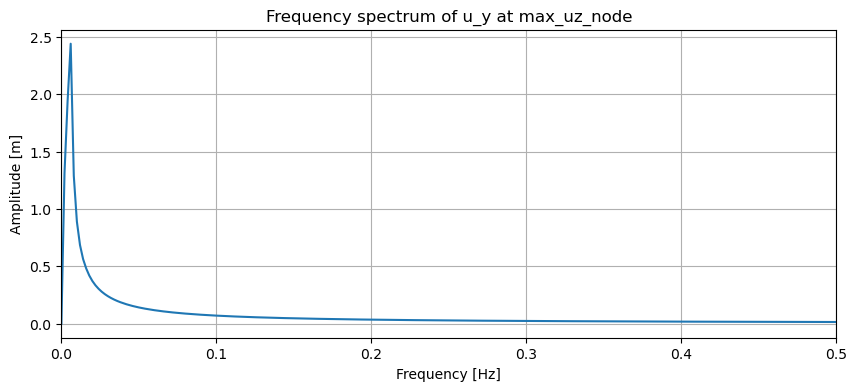

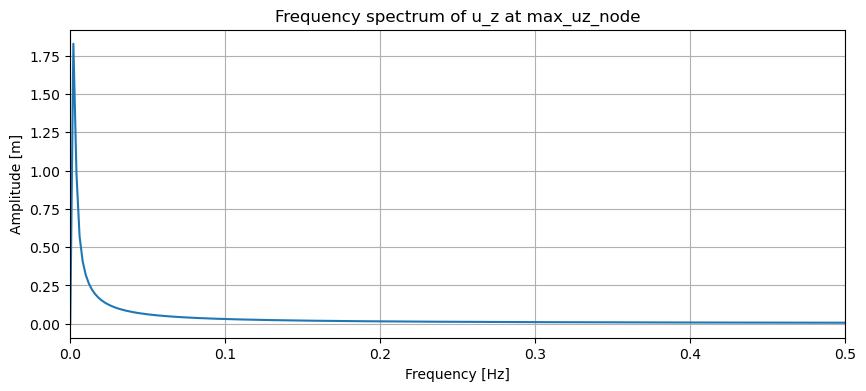

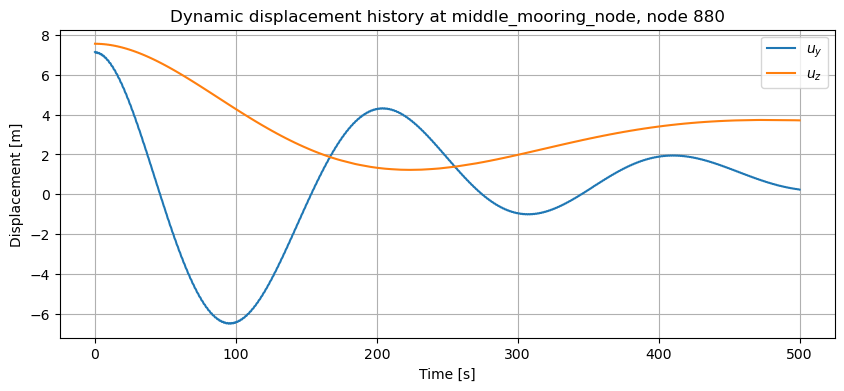

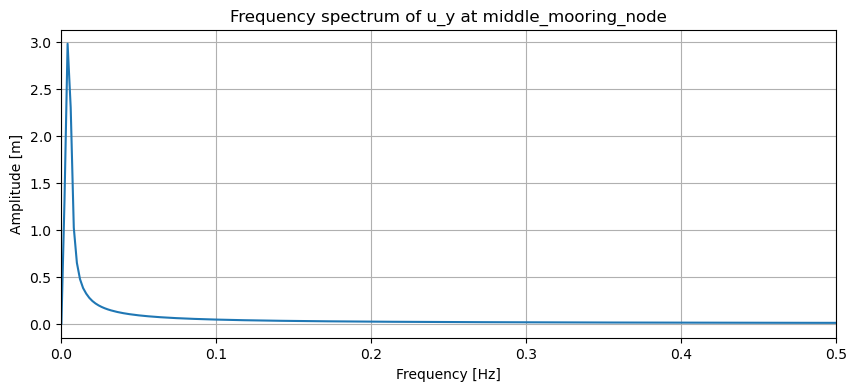

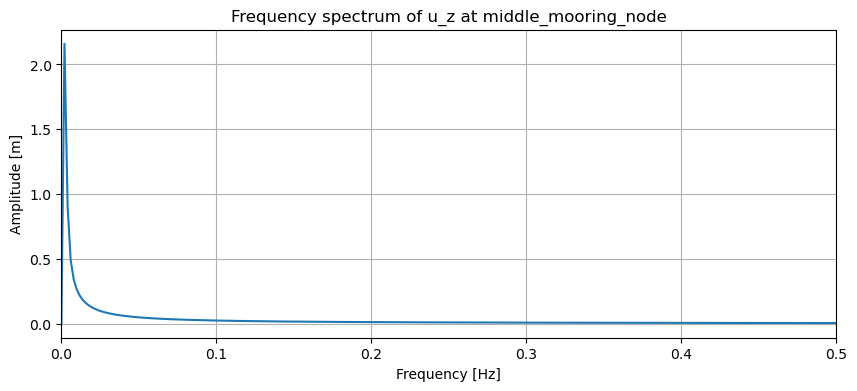

,location,node,x [m],direction,max_abs_disp [m],rms_disp [m],time_of_max [s],dominant_freq [Hz],wave_freq [Hz]
0,quarter_span,440,2750.0,y,10.962263,3.094973,0.0,0.005995,0.148148
1,quarter_span,440,2750.0,z,9.245516,5.378082,0.0,0.001998,0.148148
2,mid_span,880,5500.0,y,7.137159,3.072755,0.0,0.003997,0.148148
3,mid_span,880,5500.0,z,7.554726,3.761054,0.0,0.001998,0.148148
4,three_quarter_span,1320,8250.0,y,7.137156,2.579748,0.0,0.005995,0.148148
5,three_quarter_span,1320,8250.0,z,7.800188,4.888096,0.0,0.001998,0.148148
6,max_uy_node,420,2625.0,y,10.988758,3.078946,0.0,0.005995,0.148148
7,max_uy_node,420,2625.0,z,9.290912,5.489081,0.0,0.001998,0.148148
8,max_uz_node,398,2487.5,y,10.951587,3.050509,0.0,0.005995,0.148148
9,max_uz_node,398,2487.5,z,9.309541,5.593291,0.0,0.001998,0.148148


In [ ]:
from scipy.fft import rfft, rfftfreq



key_nodes = {
    "quarter_span": int(0.25 * (nNodes - 1)),
    "mid_span": int(0.50 * (nNodes - 1)),
    "three_quarter_span": int(0.75 * (nNodes - 1)),
}

uy_all = U_full[:, 1::LDOF]
uz_all = U_full[:, 2::LDOF]

key_nodes["max_uy_node"] = np.unravel_index(np.argmax(np.abs(uy_all)), uy_all.shape)[1]
key_nodes["max_uz_node"] = np.unravel_index(np.argmax(np.abs(uz_all)), uz_all.shape)[1]

key_nodes["middle_mooring_node"] = mooring_nodes[len(mooring_nodes)//2]


summary = []

for name, node in key_nodes.items():

    dof_y = node * LDOF + 1
    dof_z = node * LDOF + 2

    uy = U_full[:, dof_y]
    uz = U_full[:, dof_z]

    plt.figure(figsize=(10,4))
    plt.plot(t, uy, label=r"$u_y$")
    plt.plot(t, uz, label=r"$u_z$")
    plt.xlabel("Time [s]")
    plt.ylabel("Displacement [m]")
    plt.title(f"Dynamic displacement history at {name}, node {node}")
    plt.grid(True)
    plt.legend()
    plt.show()

    for direction, signal in [("y", uy), ("z", uz)]:
        sig = signal - np.mean(signal)
        freq = rfftfreq(len(sig), dt)
        amp = 2*np.abs(rfft(sig)) / len(sig)

        dominant_freq = freq[np.argmax(amp[1:]) + 1]

        plt.figure(figsize=(10,4))
        plt.plot(freq, amp)
        plt.xlim(0, 0.5)
        plt.xlabel("Frequency [Hz]")
        plt.ylabel("Amplitude [m]")
        plt.title(f"Frequency spectrum of u_{direction} at {name}")
        plt.grid(True)
        plt.show()

        summary.append({
            "location": name,
            "node": node,
            "x [m]": NodeC[node][0],
            "direction": direction,
            "max_abs_disp [m]": np.max(np.abs(signal)),
            "rms_disp [m]": np.sqrt(np.mean(signal**2)),
            "time_of_max [s]": t[np.argmax(np.abs(signal))],
            "dominant_freq [Hz]": dominant_freq,
            "wave_freq [Hz]": 1/Tp
        })

df_response = pd.DataFrame(summary)
display(df_response)

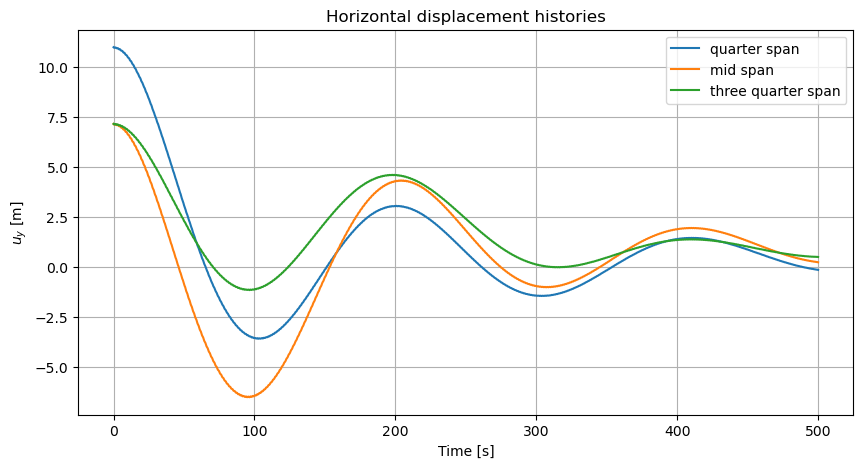

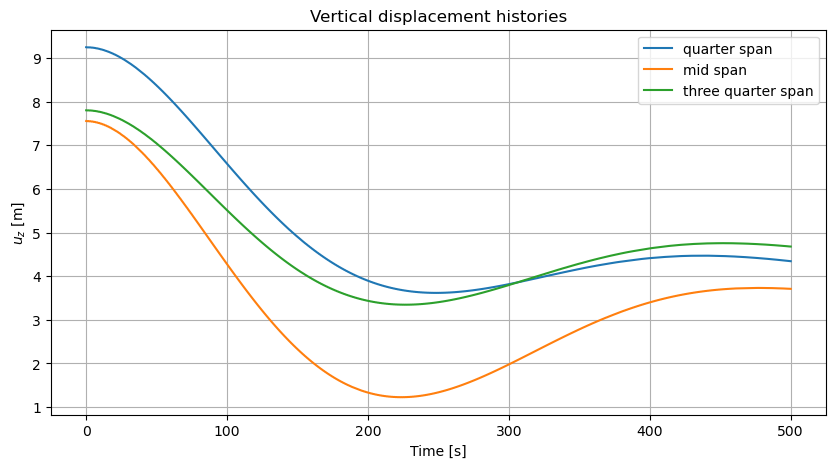

In [ ]:
from scipy.fft import rfft, rfftfreq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


key_nodes = {
    "quarter_span": int(0.25 * (nNodes - 1)),
    "mid_span": int(0.50 * (nNodes - 1)),
    "three_quarter_span": int(0.75 * (nNodes - 1)),
}


plt.figure(figsize=(10,5))

for name in ["quarter_span", "mid_span", "three_quarter_span"]:
    node = key_nodes[name]
    dof_y = node * LDOF + 1

    plt.plot(
        t,
        U_full[:, dof_y],
        label=name.replace("_", " ")
    )

plt.xlabel("Time [s]")
plt.ylabel(r"$u_y$ [m]")
plt.title("Horizontal displacement histories")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10,5))

for name in ["quarter_span", "mid_span", "three_quarter_span"]:
    node = key_nodes[name]
    dof_z = node * LDOF + 2

    plt.plot(
        t,
        U_full[:, dof_z],
        label=name.replace("_", " ")
    )

plt.xlabel("Time [s]")
plt.ylabel(r"$u_z$ [m]")
plt.title("Vertical displacement histories")
plt.grid(True)
plt.legend()
plt.show()
uy_all = U_full[:, 1::LDOF]
uz_all = U_full[:, 2::LDOF]

key_nodes["max_uy_node"] = np.unravel_index(np.argmax(np.abs(uy_all)), uy_all.shape)[1]
key_nodes["max_uz_node"] = np.unravel_index(np.argmax(np.abs(uz_all)), uz_all.shape)[1]

key_nodes["middle_mooring_node"] = mooring_nodes[len(mooring_nodes)//2]



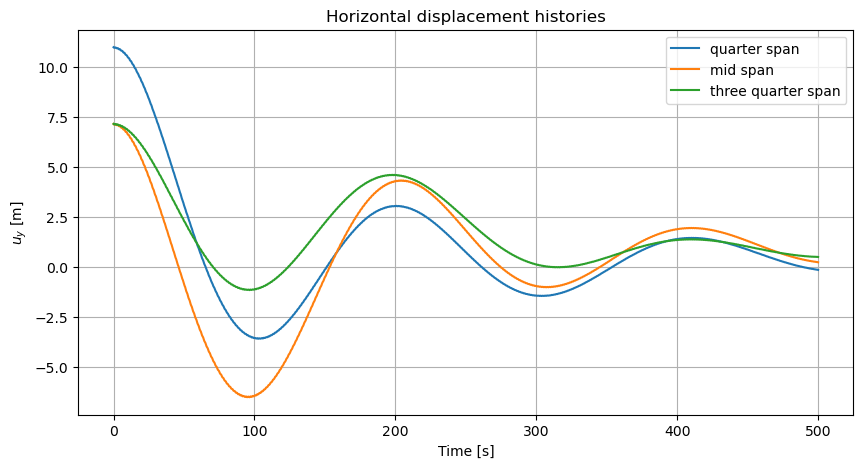

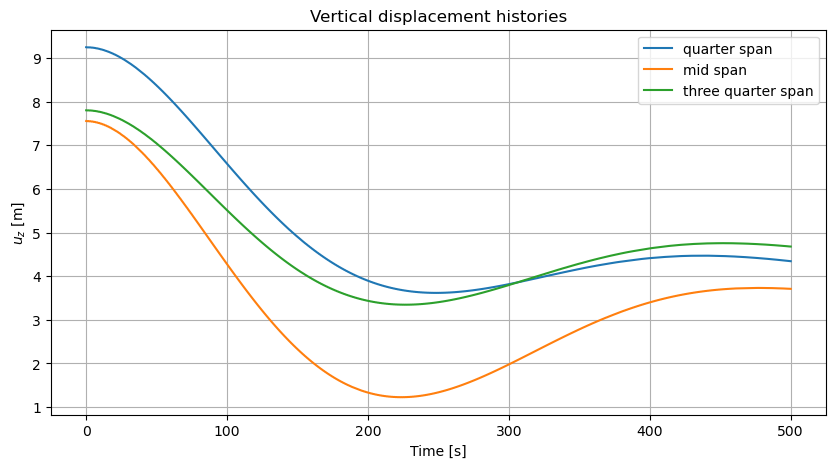

In [ ]:
plt.figure(figsize=(10,5))

for name in ["quarter_span", "mid_span", "three_quarter_span"]:
    node = key_nodes[name]
    dof_y = node * LDOF + 1

    plt.plot(
        t,
        U_full[:, dof_y],
        label=name.replace("_", " ")
    )

plt.xlabel("Time [s]")
plt.ylabel(r"$u_y$ [m]")
plt.title("Horizontal displacement histories")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10,5))

for name in ["quarter_span", "mid_span", "three_quarter_span"]:
    node = key_nodes[name]
    dof_z = node * LDOF + 2

    plt.plot(
        t,
        U_full[:, dof_z],
        label=name.replace("_", " ")
    )

plt.xlabel("Time [s]")
plt.ylabel(r"$u_z$ [m]")
plt.title("Vertical displacement histories")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:



n_moor = len(mooring_nodes)

Fy_moor = np.zeros((len(t), n_moor))
Fz_moor = np.zeros((len(t), n_moor))
Fres_moor = np.zeros((len(t), n_moor))

for j, node in enumerate(mooring_nodes):

    h_node = depth_nodes[j]

    dof_y = node * LDOF + 1
    dof_z = node * LDOF + 2

    uy = U_full[:, dof_y]
    uz = U_full[:, dof_z]

    for i in range(len(t)):

        uy_abs = np.clip(abs(uy[i]), 0.0, u_max_y)
        uz_abs = np.clip(abs(uz[i]), 0.0, u_max_z)

        ky = safe_interp(ky_lin, ky_near, h_node, uy_abs)
        kz = safe_interp(kz_lin, kz_near, h_node, uz_abs)

        Fy_moor[i, j] = ky * uy[i]
        Fz_moor[i, j] = kz * uz[i]

        Fres_moor[i, j] = np.sqrt(Fy_moor[i, j]**2 + Fz_moor[i, j]**2)

In [ ]:


max_per_mooring = np.max(np.abs(Fres_moor), axis=0)

governing_idx = np.argmax(max_per_mooring)
governing_node = mooring_nodes[governing_idx]
governing_load = max_per_mooring[governing_idx]

print("Governing mooring index:", governing_idx)
print("Governing mooring node:", governing_node)
print("Maximum resultant mooring load [N]:", governing_load)

df_mooring_summary = pd.DataFrame({
    "mooring_index": np.arange(n_moor),
    "node": mooring_nodes,
    "x [m]": [NodeC[node][0] for node in mooring_nodes],
    "max_Fy [N]": np.max(np.abs(Fy_moor), axis=0),
    "max_Fz [N]": np.max(np.abs(Fz_moor), axis=0),
    "max_Fres [N]": np.max(np.abs(Fres_moor), axis=0),
})

display(df_mooring_summary)

Governing mooring index: 91
Governing mooring node: 364
Maximum resultant mooring load [N]: 11391719.3808034


,mooring_index,node,x [m],max_Fy [N],max_Fz [N],max_Fres [N]
0,0,0,0.0,0.000000,0.000000,0.000000
1,1,4,25.0,37440.199407,573.299924,37440.573604
2,2,8,50.0,135982.013940,2241.298463,135983.817550
3,3,12,75.0,270017.586976,4937.747322,270022.598418
4,4,16,100.0,414203.810320,8598.937161,414215.742504
...,...,...,...,...,...,...
436,436,1744,10900.0,24477.088851,4437.158909,24569.980668
437,437,1748,10925.0,16301.995382,2544.539106,16340.597148
438,438,1752,10950.0,8349.417780,1153.472855,8363.693904
439,439,1756,10975.0,2316.008346,294.711585,2319.102124


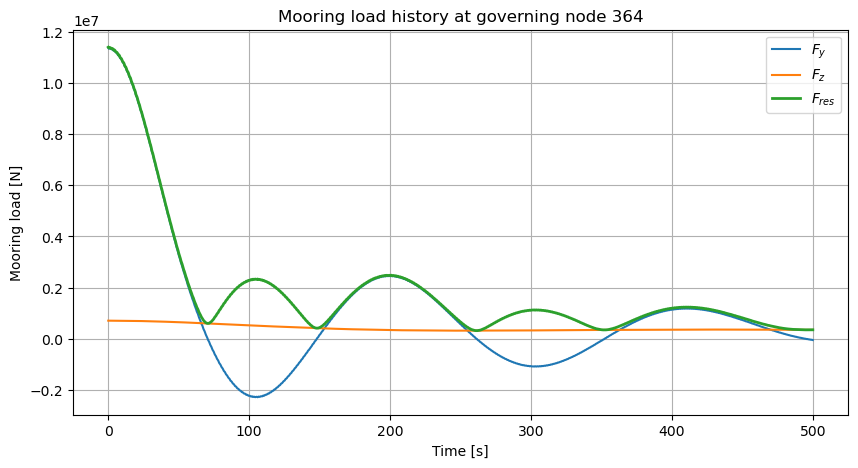

In [ ]:


plt.figure(figsize=(10,5))
plt.plot(t, Fy_moor[:, governing_idx], label=r"$F_y$")
plt.plot(t, Fz_moor[:, governing_idx], label=r"$F_z$")
plt.plot(t, Fres_moor[:, governing_idx], label=r"$F_{res}$", linewidth=2)

plt.xlabel("Time [s]")
plt.ylabel("Mooring load [N]")
plt.title(f"Mooring load history at governing node {governing_node}")
plt.grid(True)
plt.legend()
plt.show()

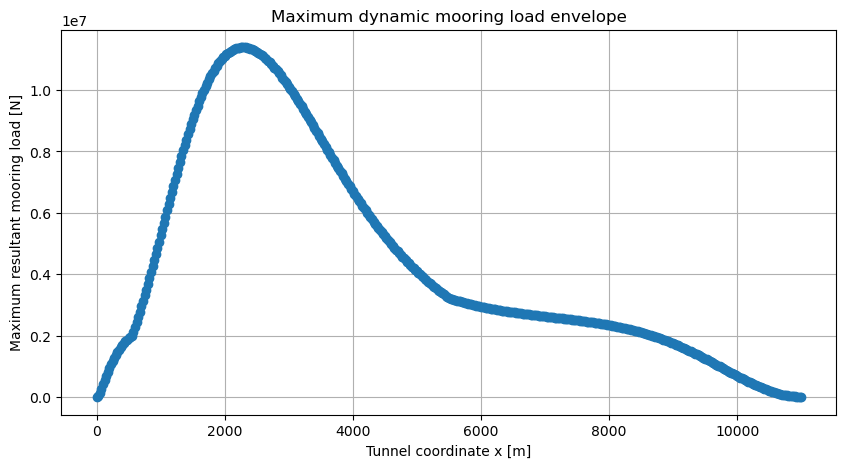

In [54]:
plt.figure(figsize=(10,5))
plt.plot(df_mooring_summary["x [m]"], df_mooring_summary["max_Fres [N]"], marker="o")

plt.xlabel("Tunnel coordinate x [m]")
plt.ylabel("Maximum resultant mooring load [N]")
plt.title("Maximum dynamic mooring load envelope")
plt.grid(True)
plt.show()